# **VAMOS A CARACTERIZAR LAS SLOPE CON LAS VARIABLES PARA EL PAQUETE A DE DATOS DE ENTRENAMIENTO**

- Datos de entrada: GeoJson de las SU con deslizamientos

- Paquete A: Misma SU donde ocurrieron los deslizamientos pero diferentes fechas (diferentes eventos)

### **AGREGAMOS GEOLOGÍA**

In [21]:
import pandas as pd
import geopandas as gpd

path_SU_si = "/home/oisanchezp/Thesis/data/raw/slope_units_eventos.geojson"
path_geo   = "/home/oisanchezp/Thesis/data/metadata/geo.geojson"

SU_si = gpd.read_file(path_SU_si)
geo   = gpd.read_file(path_geo)

# 1) Asegurar que ambas capas están en el mismo CRS
#    (idealmente un CRS proyectado en metros, pero usamos el de las Slope Units como referencia)
if geo.crs != SU_si.crs:
    geo = geo.to_crs(SU_si.crs)

# 2) Definir columna ID de la Slope Unit
id_col = "su_idx" if "su_idx" in SU_si.columns else "index"
if id_col not in SU_si.columns:
    raise ValueError("No encuentro ni 'su_idx' ni 'index' en SU_si para usar como ID de Slope Unit.")

# 3) Crear una capa de Slope Units únicas (una geometría por SU)
su_unique = SU_si[[id_col, "geometry"]].drop_duplicates(subset=id_col).copy()

# 4) Hacer overlay SU x Geología (intersección)
#    Nos quedamos sólo con 'Geologia' de la capa geo para no arrastrar basura
geo_min = geo[["Geologia", "geometry"]].copy()

su_geo_int = gpd.overlay(su_unique, geo_min, how="intersection")

# 5) Calcular área de intersección para cada combinación SU - Unidad geológica
su_geo_int["area_int"] = su_geo_int.geometry.area

# 6) Para cada Slope Unit, quedarnos con la unidad geológica que más área aporta
idx_max = su_geo_int.groupby(id_col)["area_int"].idxmax()

# su_geo_dom: una fila por Slope Unit, con la geología dominante
su_geo_dom = su_geo_int.loc[idx_max, [id_col, "Geologia"]].copy()
su_geo_dom = su_geo_dom.rename(columns={"Geologia": "geo_dom"})

# 7) Unir la geología dominante a TODAS las filas de SU_si (incluyendo eventos)
SU_si_geo = SU_si.merge(su_geo_dom, on=id_col, how="left")

# 8) (Opcional) guardar resultado
out_path = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
SU_si_geo.to_file(out_path, driver="GeoJSON")

print("Listo ✅")
print(f"Capa con geología dominante por Slope Unit: {out_path}")


Listo ✅
Capa con geología dominante por Slope Unit: /home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson


### **AGREGAMOS COBERTURAS**

- Mapa de coberturas tomado de Monica 2021

In [22]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from rasterstats import zonal_stats

path_SU_si  = "//home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
path_cober  = "/home/oisanchezp/Thesis/data/metadata/Coberturas_Valle.tif"

SU_si = gpd.read_file(path_SU_si)

# 1) Asegurar mismo CRS entre Slope Units y raster
with rasterio.open(path_cober) as src:
    raster_crs   = src.crs
    raster_nodata = src.nodata

if SU_si.crs != raster_crs:
    SU_si = SU_si.to_crs(raster_crs)

# 2) Definir ID de Slope Unit
id_col = "su_idx" if "su_idx" in SU_si.columns else "index"
if id_col not in SU_si.columns:
    raise ValueError("No encuentro ni 'su_idx' ni 'index' en SU_si para usar como ID de Slope Unit.")

# 3) Quedarnos con una geometría por Slope Unit (para no repetir trabajo)
su_unique = SU_si[[id_col, "geometry"]].drop_duplicates(subset=id_col).copy()

# 4) Zonal stats: clase de cobertura dominante (majority) dentro de cada Slope Unit
#    - stats=['majority'] -> devuelve el valor de píxel más frecuente
#    - all_touched=False -> solo píxeles cuyo centro cae dentro del polígono
#      (si quieres ser más laxo, puedes usar True)
zs = zonal_stats(
    su_unique,
    path_cober,
    stats=["majority"],
    nodata=raster_nodata,
    all_touched=False,
    geojson_out=False
)

# 5) Guardar el código de cobertura dominante en su_unique
su_unique["cov_code"] = [
    z["majority"] if z["majority"] is not None else np.nan
    for z in zs
]

# 6) Unir esa cobertura dominante a TODAS las filas de SU_si
SU_si_cov = SU_si.merge(
    su_unique[[id_col, "cov_code"]],
    on=id_col,
    how="left"
)

# 7) (Opcional) renombrar la columna a algo más explícito
SU_si_cov = SU_si_cov.rename(columns={"cov_code": "cobertura_dom"})

# 8) Guardar resultado
out_path = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
SU_si_cov.to_file(out_path, driver="GeoJSON")

print("Listo ✅")
print(f"Capa con cobertura dominante por Slope Unit: {out_path}")


Listo ✅
Capa con cobertura dominante por Slope Unit: /home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson


### **AGREGAMOS PENDIENTES Y ASPECTOS**

- Pendiente media de la Slope Unit
- Desviación estándar de la pendiente de la Slope Unit
- Aspecto medio de la Slope Unit
- Desviación estándar del aspecto de la Slope Unit

### **NOTA**: HAY QUE CORRERLO DESDE LOCAL POR QUE EL ARCHIVO DEM ES MUY PESADO PARA SUBIRLO A LA NAZCA

In [23]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

# Rutas
path_SU   = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
dem_path  = "/home/oisanchezp/Thesis/data/metadata/dem_AMVA_5m.tif"

# 1) Leer Slope Units (con eventos)
SU = gpd.read_file(path_SU)

# Definir columna ID de Slope Unit
id_col = "su_idx" if "su_idx" in SU.columns else "index"
if id_col not in SU.columns:
    raise ValueError("No encuentro ni 'su_idx' ni 'index' en la capa de Slope Units.")

# 2) Leer DEM
with rasterio.open(dem_path) as src:
    dem = src.read(1, masked=True)    # masked array
    dem_transform = src.transform
    dem_crs = src.crs
    dem_nodata = src.nodata

# 3) Asegurar mismo CRS entre SU y DEM
if SU.crs != dem_crs:
    SU = SU.to_crs(dem_crs)

# 4) Calcular pendiente y aspecto a partir del DEM
#    Obtenemos tamaño de pixel en x e y (en unidades del CRS, idealmente metros)
xres = abs(dem_transform.a)
yres = abs(dem_transform.e)

# gradiente en y (filas) y x (columnas)
gy, gx = np.gradient(dem.filled(np.nan), yres, xres)

# Pendiente (rad) y luego en grados
slope_rad = np.arctan(np.sqrt(gx**2 + gy**2))
slope_deg = np.degrees(slope_rad)

# Aspecto:
# convención típica: 0° = norte, aumenta en el sentido de las agujas del reloj
aspect_rad = np.arctan2(-gx, gy)  # ojo con el signo para que 0° sea norte
aspect_deg = np.degrees(aspect_rad)
aspect_deg = np.where(aspect_deg < 0, 360.0 + aspect_deg, aspect_deg)

# Aplicar máscara de DEM también a slope y aspect
mask = dem.mask | np.isnan(dem.filled(np.nan))
slope_deg = np.where(mask, np.nan, slope_deg)
aspect_deg = np.where(mask, np.nan, aspect_deg)

# 5) Crear Slope Units únicas (una geometría por SU)
su_unique = SU[[id_col, "geometry"]].drop_duplicates(subset=id_col).copy()

# 6) Zonal stats para pendiente: media y desviación estándar
zs_slope = zonal_stats(
    su_unique,
    slope_deg,
    affine=dem_transform,
    stats=["mean", "std"],
    nodata=np.nan,
    all_touched=False,
    geojson_out=False
)

su_unique["slope_mean"] = [z["mean"] for z in zs_slope]
su_unique["slope_std"]  = [z["std"]  for z in zs_slope]

# 7) Zonal stats para aspecto: media y desviación estándar (lineal)
# Nota: esto trata el aspecto como variable lineal; si luego quieres
# algo más fino (estadística circular), lo podemos refinar.
zs_aspect = zonal_stats(
    su_unique,
    aspect_deg,
    affine=dem_transform,
    stats=["mean", "std"],
    nodata=np.nan,
    all_touched=False,
    geojson_out=False
)

su_unique["aspect_mean"] = [z["mean"] for z in zs_aspect]
su_unique["aspect_std"]  = [z["std"]  for z in zs_aspect]

# 8) Unir estas estadísticas a TODAS las filas de la capa original (con eventos)
SU_stats = SU.merge(
    su_unique[[id_col, "slope_mean", "slope_std", "aspect_mean", "aspect_std"]],
    on=id_col,
    how="left"
)

# 9) Guardar resultado
out_path = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
SU_stats.to_file(out_path, driver="GeoJSON")

print("Listo ✅")
print(f"Guardado en: {out_path}")


Listo ✅
Guardado en: /home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson


### **AGREGAMOS COLUMNA MES Y COLUMNA ENSO DEPENDIENDO DEL DÍA**



#### **MES**

In [25]:
import pandas as pd
import geopandas as gpd

# Ajusta la ruta según el último archivo que estés usando
path_SU = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"

SU = gpd.read_file(path_SU)

# 1) Asegurar que la fecha es tipo datetime
SU["fecha_hora_evento"] = pd.to_datetime(SU["fecha_hora_evento"], errors="coerce")

# 2) Crear columna Mes (1–12)
SU["Mes"] = SU["fecha_hora_evento"].dt.month

# (Opcional) si quieres que sea entero puro sin NaN:
# SU["Mes"] = SU["Mes"].fillna(0).astype(int)

# 3) Guardar con la nueva columna
out_path = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
SU.to_file(out_path, driver="GeoJSON")

print("Listo ✅")
print(f"Capa con columna Mes guardada en: {out_path}")


Listo ✅
Capa con columna Mes guardada en: /home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson


#### **DÍA DEL AÑO: DOY**

In [26]:
import pandas as pd
import geopandas as gpd

# Ajusta la ruta según el último archivo que estés usando
path_SU = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"

SU = gpd.read_file(path_SU)

# 1) Asegurar que la fecha es tipo datetime
SU["fecha_hora_evento"] = pd.to_datetime(SU["fecha_hora_evento"], errors="coerce")

# 2) Crear columna Mes (1–12)
SU["Mes"] = SU["fecha_hora_evento"].dt.month

# 3) Crear columna DoY (Day of Year: 1–365 o 1–366)
SU["DoY"] = SU["fecha_hora_evento"].dt.dayofyear

# Si quieres que Mes y DoY sean enteros sin NaN (por ejemplo, reemplazar NaN por 0):
# SU["Mes"] = SU["Mes"].fillna(0).astype(int)
# SU["DoY"] = SU["DoY"].fillna(0).astype(int)

# 4) Guardar con las nuevas columnas
out_path = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
SU.to_file(out_path, driver="GeoJSON")

print("Listo ✅")
print(f"Capa con columnas Mes y DoY guardada en: {out_path}")


Listo ✅
Capa con columnas Mes y DoY guardada en: /home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson


#### **ENSO**

In [27]:
import pandas as pd
import numpy as np

# Ruta de la tabla que tú vas a construir a partir de la imagen
oni_csv = "/home/oisanchezp/Thesis/data/metadata/ENSO.csv"

# 1) Leer tabla trimestral
oni_tri = pd.read_csv(oni_csv)

# 2) Pasar de formato ancho (DJF, JFM, ...) a largo
oni_long = oni_tri.melt(
    id_vars="Year",
    var_name="Season",
    value_name="ONI"
)

# 3) Mapeo de mes -> Season (según tu interpretación de la tabla)
month_to_season = {
    1: "DJF",
    2: "JFM",
    3: "FMA",
    4: "MAM",
    5: "AMJ",
    6: "MJJ",
    7: "JJA",
    8: "JAS",
    9: "ASO",
    10: "SON",
    11: "OND",
    12: "NDJ",
}

# 4) Crear un rango diario desde 2010-01-01 hasta 2025-12-31
dates = pd.date_range("2010-01-01", "2025-12-31", freq="D")
df_days = pd.DataFrame({"date": dates})
df_days["Year"] = df_days["date"].dt.year
df_days["Month"] = df_days["date"].dt.month

# 5) Añadir la Season que corresponde a cada mes
df_days["Season"] = df_days["Month"].map(month_to_season)

# 6) Unir con la tabla de ONI trimestral (Year + Season)
df_days = df_days.merge(
    oni_long,
    on=["Year", "Season"],
    how="left"
)

# 7) Clasificar ENSO a partir del valor de ONI
#    Umbrales típicos:
#    ONI >=  0.5 -> El Niño (rojo)
#    ONI <= -0.5 -> La Niña (azul)
#    |ONI| < 0.5 -> Neutro (negro)

def clasificar_enso(oni):
    if pd.isna(oni):
        return np.nan
    if oni >= 0.5:
        return "El Niño"
    elif oni <= -0.5:
        return "La Niña"
    else:
        return "Neutro"

df_days["ENSO"] = df_days["ONI"].apply(clasificar_enso)

# --- Excepciones manuales donde, a pesar del ONI, se declaró Neutro ---

exc_neutro = (
    # Noviembre y diciembre 2019
    ((df_days["Year"] == 2019) & df_days["Month"].isin([11, 12])) |
    # Enero y febrero 2020
    ((df_days["Year"] == 2020) & df_days["Month"].isin([1, 2])) |
    # Diciembre 2024
    ((df_days["Year"] == 2024) & (df_days["Month"] == 12)) |
    # Enero y septiembre 2025
    ((df_days["Year"] == 2025) & df_days["Month"].isin([1, 9])) |
    # Febrero 2014
    ((df_days["Year"] == 2014) & (df_days["Month"] == 2))
)

df_days.loc[exc_neutro, "ENSO"] = "Neutro"

# 8) (Opcional) ordenar columnas y guardar
df_days = df_days[["date", "Year", "Month", "ONI", "ENSO"]]

out_csv = "/home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv"
df_days.to_csv(out_csv, index=False)

print("Listo ✅")
print(f"Archivo diario guardado en: {out_csv}")
print(df_days.head())


Listo ✅
Archivo diario guardado en: /home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv
        date  Year  Month  ONI     ENSO
0 2010-01-01  2010      1  1.5  El Niño
1 2010-01-02  2010      1  1.5  El Niño
2 2010-01-03  2010      1  1.5  El Niño
3 2010-01-04  2010      1  1.5  El Niño
4 2010-01-05  2010      1  1.5  El Niño


In [28]:
import pandas as pd
import geopandas as gpd

# Ajusta estas rutas a tus archivos reales
path_SU  = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
path_oni = "/home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv"

# 1) Leer capa de Slope Units con eventos
SU = gpd.read_file(path_SU)

# Asegurar tipo datetime en la fecha del evento
SU["fecha_hora_evento"] = pd.to_datetime(SU["fecha_hora_evento"], errors="coerce")

# Crear columna 'date' solo con la fecha (hora a medianoche)
SU["date"] = SU["fecha_hora_evento"].dt.normalize()   # equivalente a .dt.floor("D")

# 2) Leer tabla diaria de ONI/ENSO
oni = pd.read_csv(path_oni)

# Asegurar que 'date' es datetime
oni["date"] = pd.to_datetime(oni["date"])

# 3) Hacer el join por fecha
#    Nos quedamos solo con las columnas necesarias de la tabla ONI
SU_enso = SU.merge(
    oni[["date", "ONI", "ENSO"]],
    on="date",
    how="left"
)

# 4) Volver a GeoDataFrame (por seguridad) y guardar
SU_enso = gpd.GeoDataFrame(SU_enso, geometry="geometry", crs=SU.crs)

out_path = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
SU_enso.to_file(out_path, driver="GeoJSON")

print("Listo ✅")
print(f"Capa con ONI y ENSO asignados guardada en: {out_path}")


Listo ✅
Capa con ONI y ENSO asignados guardada en: /home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson


### **AGREGAMOS COLUMNA ZONA DE LLUVIA Y TIPO DE SLOPE UNIT**



### **CALCULAMOS ACUMULADOS DE CORTO Y LARGO PLAZO PARA CADA EVENTO**



In [29]:
import pandas as pd
import numpy as np
import os
from geopy.distance import geodesic
import geopandas as gpd

# Si necesitas funciones adicionales, mantén tu import:
# from funciones import *

# --------- CARGAMOS SLOPE UNITS CON EVENTOS -------------
# GeoJSON con una fila por deslizamiento + atributos de SU
path_su_eventos = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"
# Leer como GeoDataFrame
SU_gdf = gpd.read_file(path_su_eventos)

# Si solo quieres trabajar como tabla (sin geometría) para lluvia:
SU = pd.DataFrame(SU_gdf.drop(columns="geometry"))
# Si prefieres usar GeoPandas:
# import geopandas as gpd
# SU_gdf = gpd.read_file(path_su_eventos)
# SU = pd.DataFrame(SU_gdf.drop(columns="geometry"))

pluvios = pd.read_csv("/home/oisanchezp/Thesis/data/metadata/pluviometros_metadatos_20250506.csv")

# --- Asegurar tipos de fecha ---
SU["fecha_hora_evento"] = pd.to_datetime(SU["fecha_hora_evento"])
pluvios["FechaInstalacion"] = pd.to_datetime(pluvios["FechaInstalacion"])

# Ruta a los datos horarios de los pluviómetros
ruta_datos_horarios = "/mnt/investigacion/geotecnia/Pluvios_horarios/Pluvios_horarios_completos/"

# ----------- Función para encontrar pluviómetro con datos válidos ----------
#   Igual que antes, pero ahora recibe evento desde la tabla de SU
# ---------------------------------------------------------------------------
def encontrar_pluviometro_con_datos(fecha_evento, lat_evento, lon_evento):
    # 1) Pluviómetros instalados antes del evento
    pluvios_inst = pluvios[pluvios["FechaInstalacion"] <= fecha_evento].copy()
    if pluvios_inst.empty:
        return None, [None]*97

    # 2) Calcular distancia a TODOS los pluviómetros instalados
    pluvios_inst["Distancia"] = pluvios_inst.apply(
        lambda r: geodesic(
            (lat_evento, lon_evento),
            (r["Latitude"], r["Longitude"])
        ).kilometers,
        axis=1
    )

    # Función interna para probar una lista de candidatos ordenados por distancia
    def probar_candidatos(df_cand):
        for _, pluvio in df_cand.sort_values("Distancia").iterrows():
            codigo = pluvio["Codigo"]
            ruta = os.path.join(
                ruta_datos_horarios,
                f"H_Datos_Procesados_Est_{codigo}.csv"
            )
            if not os.path.exists(ruta):
                continue

            datos = pd.read_csv(ruta, parse_dates=["Fecha"]).set_index("Fecha")

            # Intervalo 97 días
            inicio_97d = fecha_evento - pd.Timedelta(days=97)
            intervalo_97d = datos.loc[inicio_97d:fecha_evento]
            if intervalo_97d.empty:
                continue

            # Verificación: últimos 7 días con datos horarios
            inicio_7d = fecha_evento - pd.Timedelta(days=6)
            dias_con_datos = datos.loc[inicio_7d:fecha_evento]["P"].resample("D").count()
            if (dias_con_datos == 0).any():
                # al menos un día sin datos -> probar siguiente pluviómetro
                continue

            # Calcular acumulados 1–97 días (terminando en fecha_evento)
            acumulados = []
            for d in range(1, 98):
                lluvia = datos.loc[fecha_evento - pd.Timedelta(days=d):fecha_evento]["P"].sum()
                acumulados.append(lluvia)

            return codigo, acumulados

        return None, None

    # 3) PRIMER INTENTO: solo pluviómetros a ≤ 5 km
    cand_5km = pluvios_inst[pluvios_inst["Distancia"] <= 5].copy()
    if not cand_5km.empty:
        codigo, acumulados = probar_candidatos(cand_5km)
        if codigo is not None:
            return codigo, acumulados

    # 4) SEGUNDO INTENTO (fallback): el más cercano con datos, sin límite de distancia
    codigo, acumulados = probar_candidatos(pluvios_inst)
    if codigo is not None:
        return codigo, acumulados

    # 5) Si de verdad ninguno sirve
    return None, [None]*97



# ----------------- Crear nuevo DataFrame con lluvia acumulada ----------------
datos_nuevo_df = []

# Iterar sobre cada evento en la tabla de Slope Units
for idx, evento in SU.iterrows():
    print(f'Procesando evento {idx+1}/{len(SU)}')

    fecha_evt = evento["fecha_hora_evento"]
    lat_evt   = evento["latitud"]
    lon_evt   = evento["longitud"]

    codigo_pluviometro, acumulados_lluvia = encontrar_pluviometro_con_datos(
        fecha_evt, lat_evt, lon_evt
    )

    # Diccionario base: puedes incluir todas las columnas originales que quieras
    datos_evento = {
        "su_idx": evento.get("su_idx", np.nan),
        "index": evento.get("index", np.nan),
        "fecha_hora_evento": fecha_evt,
        "latitud": lat_evt,
        "longitud": lon_evt,
        "municipio": evento.get("municipio", None),
        "vereda_barrio": evento.get("vereda_barrio", None),
        "zona_lluvia": evento.get("zona", None),
        "tipo_slope_unit": evento.get("cluster4", None),
        "Codigo_pluvio_lluvia": codigo_pluviometro,  # código del pluvio usado para el cálculo
    }

    # Agregar todas las demás columnas que ya tenías (geo, coberturas, pendientes, ENSO, etc.)
    # por ejemplo:
    for col in ["geo_dom", "cobertura_dom", "slope_mean", "slope_std",
                "aspect_mean", "aspect_std", "Mes", "DoY", "ONI", "ENSO"]:
        if col in evento.index:
            datos_evento[col] = evento[col]

    # Agregar acumulados de lluvia al diccionario: 1d, 2d, ..., 97d
    for i in range(1, 98):
        datos_evento[f"{i}d"] = acumulados_lluvia[i-1]

    datos_nuevo_df.append(datos_evento)

# Crear el nuevo DataFrame
lluvia_df = pd.DataFrame(datos_nuevo_df)

# Guardar el nuevo DataFrame a un archivo CSV
out_csv = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.csv"
lluvia_df.to_csv(out_csv, index=False)

print("Listo ✅")
print(f"El nuevo DataFrame con lluvia acumulada ha sido guardado en: {out_csv}")


Procesando evento 1/469
Procesando evento 2/469
Procesando evento 3/469
Procesando evento 4/469
Procesando evento 5/469
Procesando evento 6/469
Procesando evento 7/469
Procesando evento 8/469
Procesando evento 9/469
Procesando evento 10/469
Procesando evento 11/469
Procesando evento 12/469
Procesando evento 13/469
Procesando evento 14/469
Procesando evento 15/469
Procesando evento 16/469
Procesando evento 17/469
Procesando evento 18/469
Procesando evento 19/469
Procesando evento 20/469
Procesando evento 21/469
Procesando evento 22/469
Procesando evento 23/469
Procesando evento 24/469
Procesando evento 25/469
Procesando evento 26/469
Procesando evento 27/469
Procesando evento 28/469
Procesando evento 29/469
Procesando evento 30/469
Procesando evento 31/469
Procesando evento 32/469
Procesando evento 33/469
Procesando evento 34/469
Procesando evento 35/469
Procesando evento 36/469
Procesando evento 37/469
Procesando evento 38/469
Procesando evento 39/469
Procesando evento 40/469
Procesand

In [30]:
#FILTRO PARA ELIMANAR DATOS POR PLUVIOS MALOS O MUY LEJOS

out_csv = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.csv"

lluvia_df = pd.read_csv(out_csv)

print(len(lluvia_df))

lluvia_df = lluvia_df[
    (lluvia_df["2d"] >= 10)  &
    (lluvia_df["3d"] >= 20)  &
    (lluvia_df["4d"] >= 30)  &
    (lluvia_df['7d'] > 40)   &
    (lluvia_df["91d"] >= 100)
]

print(len(lluvia_df))

#guardar con el mismo nombre
lluvia_df.to_csv(out_csv, index=False)


469
458


#### **VOLVER A GEOJSON**

In [31]:
import geopandas as gpd
import pandas as pd
import numpy as np

# Capa original con geometría de Slope Unit + eventos
path_su_geo = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.geojson"

# CSV que generaste con lluvia 1d..97d
path_lluvia = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.csv"

su_gdf = gpd.read_file(path_su_geo)
lluvia_df = pd.read_csv(path_lluvia)

su_gdf["fecha_hora_evento"] = pd.to_datetime(su_gdf["fecha_hora_evento"], errors="coerce")
lluvia_df["fecha_hora_evento"] = pd.to_datetime(lluvia_df["fecha_hora_evento"], errors="coerce")


keys = ["su_idx", "fecha_hora_evento", "latitud", "longitud"]


# columnas de lluvia: Codigo pluvio + 1d..97d
cols_lluvia = ["Codigo_pluvio_lluvia"] + [f"{i}d" for i in range(1, 98)]

# sub-dataframe solo con llaves + lluvia
lluvia_sub = lluvia_df[keys + cols_lluvia].copy()


su_lluvia = su_gdf.merge(
    lluvia_sub,
    on=keys,
    how="left"
)

# Asegurarse de que sigue siendo GeoDataFrame
su_lluvia = gpd.GeoDataFrame(su_lluvia, geometry="geometry", crs=su_gdf.crs)

out_gpkg = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos_lluvia.gpkg"
su_lluvia.to_file(out_gpkg, layer="su_eventos_lluvia", driver="GPKG")


### **ESCOGEMOS EVENTOS DE FECHAS ALEATORIAS DE NO EVENTOS**



In [32]:
import os
import numpy as np
import pandas as pd

# -------------------------
# Entradas
# -------------------------
su_si_path  = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.csv"  # eventos SÍ (Slope Units)
pluv_meta   = "/home/oisanchezp/Thesis/data/metadata/pluviometros_metadatos_20250506.csv"
ruta_series = "/mnt/investigacion/geotecnia/Pluvios_horarios/Pluvios_horarios_completos/"
oni_path    = "/home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv"

out_path    = "/home/oisanchezp/Thesis/data/processed/slope_units_si_no_20251115.csv"
seed        = 42

# Umbrales de lluvia
UMBRAL_1D  = 5
UMBRAL_7D  = 10
UMBRAL_90D = 100

# ventanas en horas
H1   = 24
H7   = 7 * 24
H90  = 90 * 24

# -------------------------
# 1) Cargar inventario de SÍ (Slope Units) y días excluidos ±30
# -------------------------
su_si = pd.read_csv(su_si_path, parse_dates=["fecha_hora_evento"])

# Asegura que tenga si_no=1
if "si_no" not in su_si.columns:
    su_si["si_no"] = 1
else:
    su_si.loc[:, "si_no"] = 1  # por si acaso

# Días a excluir (por día) ±30 alrededor de cada evento SÍ
excluidas = pd.Index(
    np.unique(
        np.concatenate([
            pd.date_range(d.normalize() - pd.Timedelta(days=30),
                          d.normalize() + pd.Timedelta(days=30),
                          freq="D").date
            for d in su_si["fecha_hora_evento"]
        ])
    )
)

# -------------------------
# 2) Precargar series y armar candidatos (fechas+pluviómetro)
# -------------------------
pluvios = pd.read_csv(pluv_meta)

# Opcional: restringir a pluviómetros que ya usaste en su_si
# (garantiza asignarles una Slope Unit existente)
if "Codigo_pluvio_lluvia" in su_si.columns:
    codigos_usable = su_si["Codigo_pluvio_lluvia"].dropna().unique()
    pluvios = pluvios[pluvios["Codigo"].isin(codigos_usable)].copy()

candidatos = []
series_acum = {}   # guarda cumsum por código para reutilizar

rng = np.random.default_rng(seed)

for _, p in pluvios.iterrows():
    cod = p["Codigo"]
    fn  = f"H_Datos_Procesados_Est_{cod}.csv"
    path = os.path.join(ruta_series, fn)
    if not os.path.exists(path):
        continue

    # Leer serie horaria
    df = pd.read_csv(path, usecols=["Fecha", "P"], parse_dates=["Fecha"])
    serie_h = (df.groupby("Fecha")["P"].sum()
                 .sort_index()
                 .asfreq("H", fill_value=0.0))

    # Cumulada para diferencias rápidas
    cs = serie_h.cumsum().astype(np.float32)
    series_acum[cod] = cs

    idx = cs.index

    # Lluvias acumuladas 1d, 7d, 90d
    ll_1d  = cs - cs.shift(H1)
    ll_7d  = cs - cs.shift(H7)
    ll_90d = cs - cs.shift(H90)

    # Fuera de ventanas excluidas, comparando por DÍA
    fuera_ventanas = ~idx.normalize().isin(excluidas)

    # Candidatos que cumplen umbrales
    mask_ok = (
        fuera_ventanas &
        (ll_1d  >= UMBRAL_1D) &
        (ll_7d  >= UMBRAL_7D) &
        (ll_90d >= UMBRAL_90D)
    )

    fechas_ok = idx[mask_ok]
    if len(fechas_ok):
        # Guardar (timestamp, código) como candidatos
        candidatos.extend([(f, cod) for f in fechas_ok])

# Quitar duplicados si los hubiera (mismo timestamp+código)
candidatos = list({(f, c) for (f, c) in candidatos})

# -------------------------
# 3) Muestreo: 2× eventos SÍ
# -------------------------
n_si = len(su_si)
n_no_target = 2 * n_si

if len(candidatos) < n_no_target:
    raise ValueError(
        f"No hay suficientes candidatos que cumplan umbrales y ventanas: "
        f"necesitas {n_no_target}, hay {len(candidatos)}."
    )

muestras = rng.choice(candidatos, size=n_no_target, replace=False)

# -------------------------
# 4) Preparar estructura de columnas: estáticas vs dinámicas
# -------------------------
lluvia_cols = [f"{d}d" for d in range(1, 98)]
dynamic_cols = set(["fecha_hora_evento", "Mes", "ONI", "ENSO", "DoY", "si_no"] + lluvia_cols)

# columnas estáticas (se copian de una SU real asociada al pluviómetro)
static_cols = [c for c in su_si.columns if c not in dynamic_cols]

# -------------------------
# 5) Construir NO-eventos con acumulados
# -------------------------
filas = []

for fecha, cod in muestras:
    cs = series_acum[cod]

    # Asegurarse de que la fecha esté en el índice (o la anterior)
    if fecha not in cs.index:
        try:
            pos = cs.index.get_loc(fecha, method="pad")
        except KeyError:
            # si no encuentra nada, saltamos este candidato
            continue
    else:
        pos = cs.index.get_loc(fecha)

    # Necesitamos al menos 97 días (97*24 h) hacia atrás
    if pos < 97 * H1:
        continue

    # Acumulados 1–97 días hacia atrás
    vals = cs.iloc[pos] - cs.iloc[pos - np.arange(1, 98) * H1].values

    # Buscar una Slope Unit asociada a este pluviómetro
    if "Codigo_pluvio_lluvia" in su_si.columns:
        su_candidatas = su_si[su_si["Codigo_pluvio_lluvia"] == cod]
    else:
        su_candidatas = su_si

    if su_candidatas.empty:
        # No tenemos SU asociadas a este pluvio, saltamos
        continue

    # Elegimos una SU al azar entre las que usan ese pluviómetro
    base = su_candidatas.sample(1, random_state=rng.integers(0, 10**9)).iloc[0]

    fila = {}

    # Copiamos todas las columnas estáticas desde esa SU
    for col in static_cols:
        fila[col] = base[col]

    # Dinámicas redefinidas
    fila["fecha_hora_evento"] = pd.Timestamp(fecha)
    fila["si_no"] = 0
    fila["Mes"] = fecha.month
    fila["DoY"] = fecha.dayofyear

    # Código de pluviómetro usado para lluvia (si existe en columnas estáticas, lo sobreescribimos)
    if "Codigo_pluvio_lluvia" in su_si.columns:
        fila["Codigo_pluvio_lluvia"] = cod
    else:
        fila["Codigo"] = cod

    # Lluvia 1–97 días
    for d in range(1, 98):
        fila[f"{d}d"] = float(vals[d-1])

    filas.append(fila)

df_no = pd.DataFrame(filas)

# Reaplica filtro de umbrales por si alguna fecha quedó al borde de la serie
df_no = df_no[
    (df_no["1d"]  >= UMBRAL_1D) &
    (df_no["7d"]  >= UMBRAL_7D) &
    (df_no["90d"] >= UMBRAL_90D)   # si usas 90d explícito; si no, ajusta a 91d
].copy()

# Si tras la verificación hay más de lo necesario, recorta aleatoriamente al objetivo
if len(df_no) > n_no_target:
    df_no = df_no.sample(n=n_no_target, random_state=seed)

# -------------------------
# 6) Añadir ONI y ENSO a los NO-eventos
# -------------------------
oni_df = pd.read_csv(oni_path, parse_dates=["date"])

df_no["date"] = df_no["fecha_hora_evento"].dt.normalize()

df_no = df_no.merge(
    oni_df[["date", "ONI", "ENSO"]],
    on="date",
    how="left"
).drop(columns=["date"])

# -------------------------
# 7) Unir SI y NO y guardar
# -------------------------
df_si = su_si.copy()

# Nos aseguramos de que df_no tenga todas las columnas de df_si; las que falten se rellenan con NaN
for col in df_si.columns:
    if col not in df_no.columns:
        df_no[col] = np.nan

# Alineamos orden de columnas
df_no = df_no[df_si.columns]

df_combined = pd.concat([df_si, df_no], axis=0, ignore_index=True)

df_combined.to_csv(out_path, index=False)

print(f"Eventos SÍ: {len(df_si)}  |  NO-eventos: {len(df_no)}  |  Total: {len(df_combined)}")
print(f"Guardado en: {out_path}")



Eventos SÍ: 458  |  NO-eventos: 914  |  Total: 1372
Guardado en: /home/oisanchezp/Thesis/data/processed/slope_units_si_no_20251115.csv


In [33]:
print(df_combined.columns)

Index(['su_idx', 'index', 'fecha_hora_evento', 'latitud', 'longitud',
       'municipio', 'vereda_barrio', 'zona_lluvia', 'tipo_slope_unit',
       'Codigo_pluvio_lluvia',
       ...
       '89d', '90d', '91d', '92d', '93d', '94d', '95d', '96d', '97d', 'si_no'],
      dtype='object', length=118)


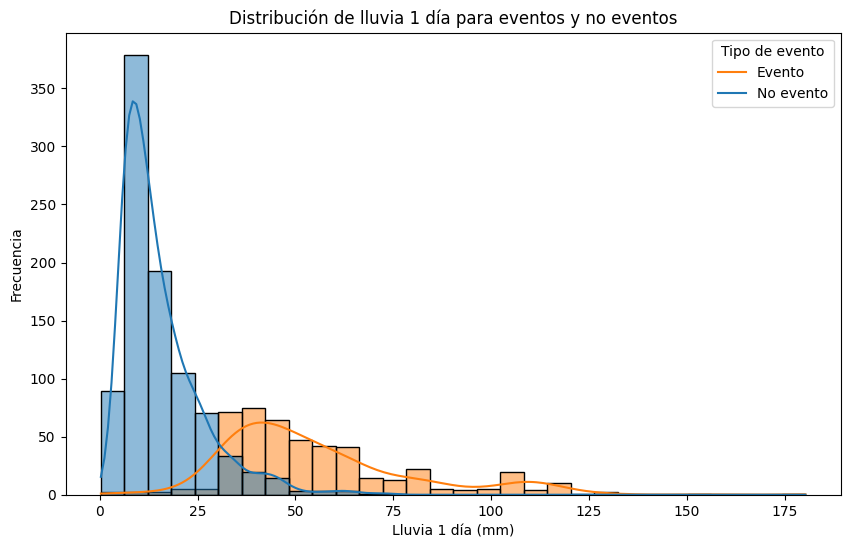

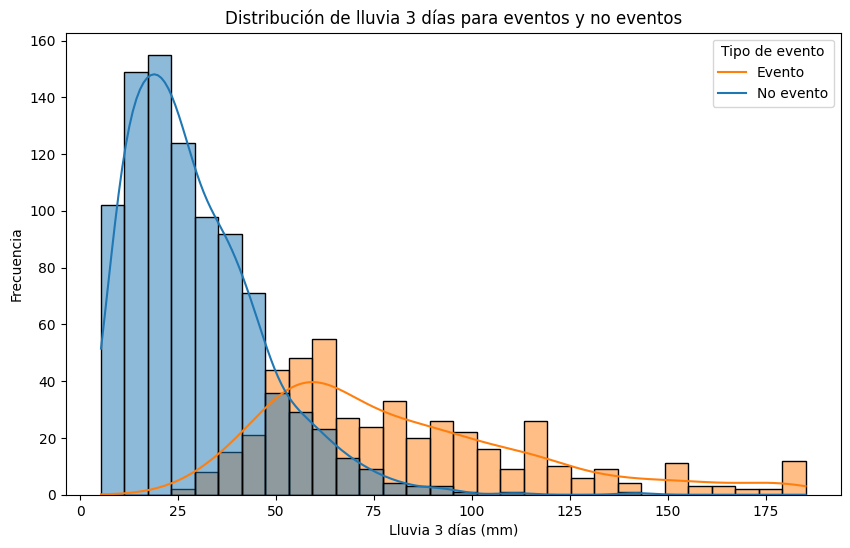

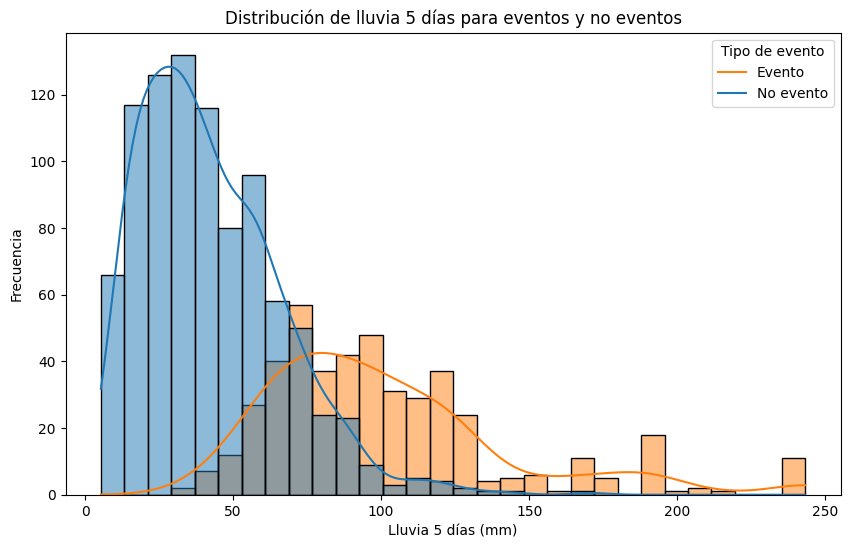

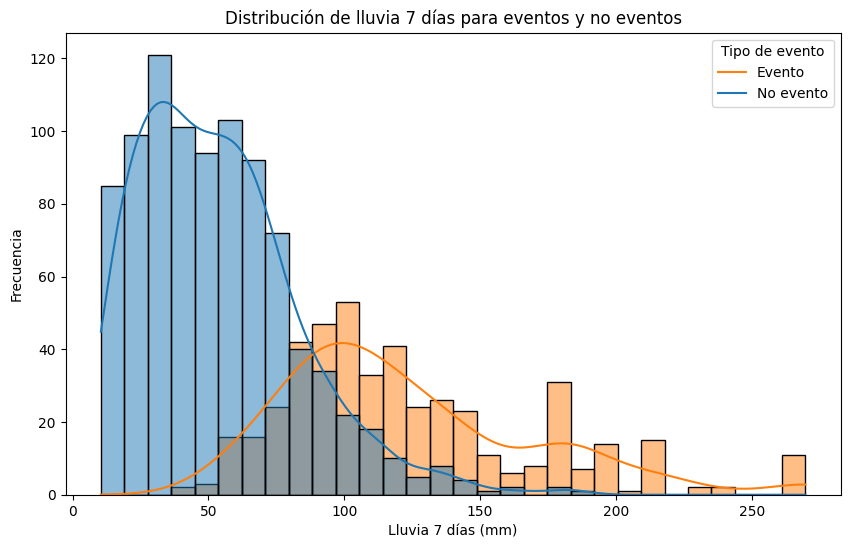

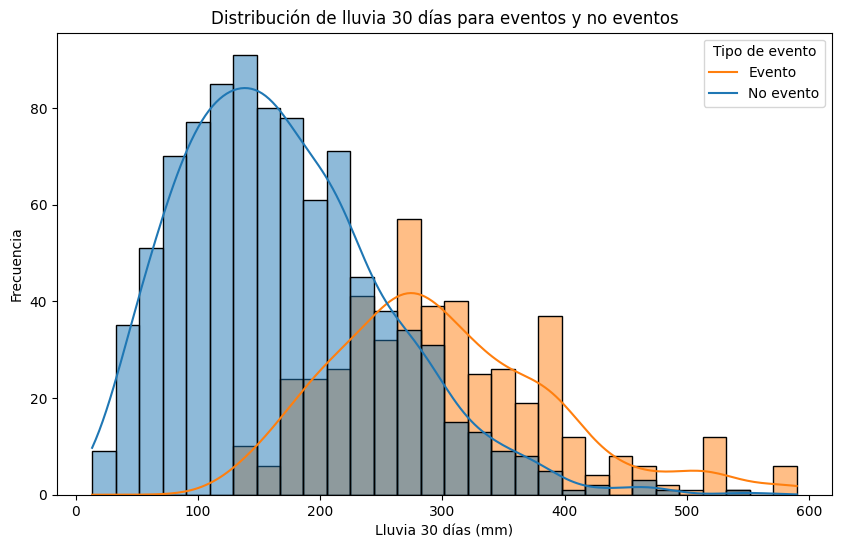

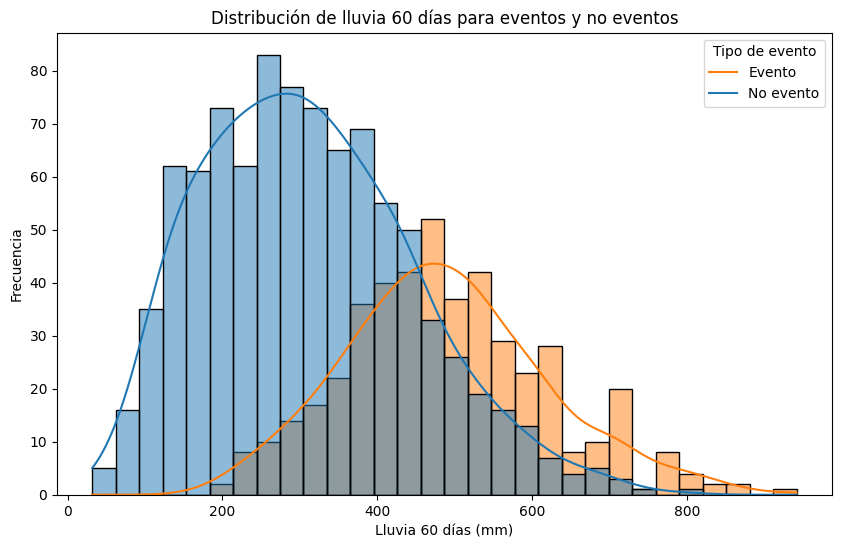

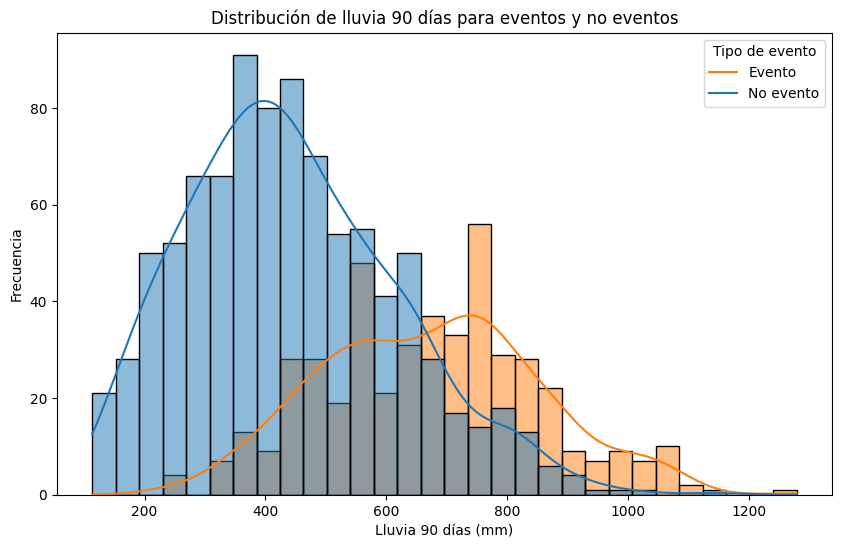

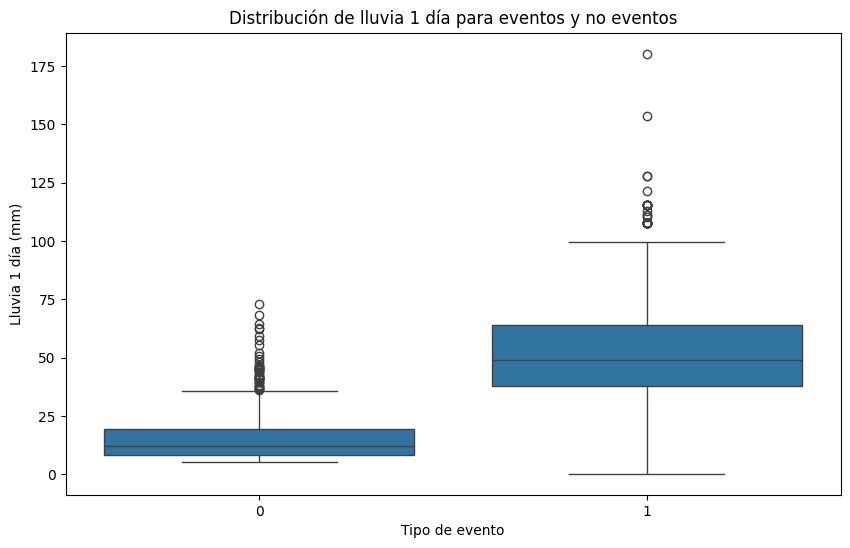

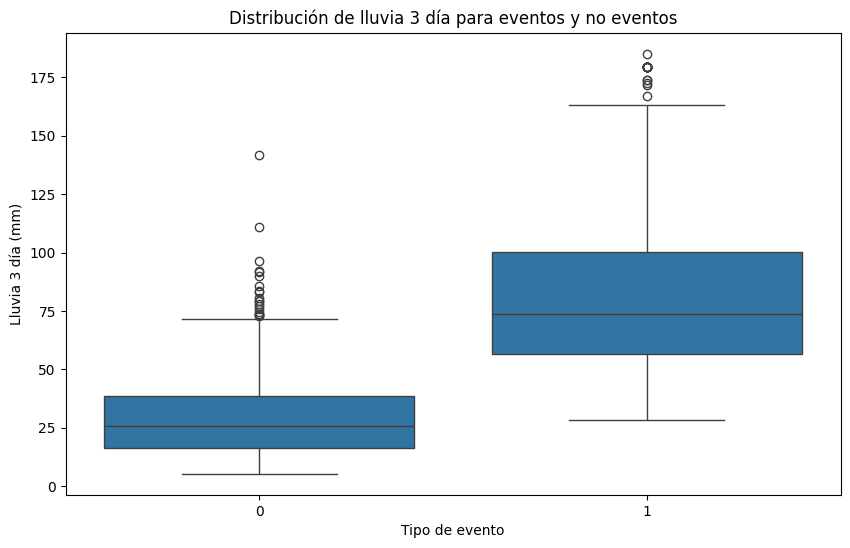

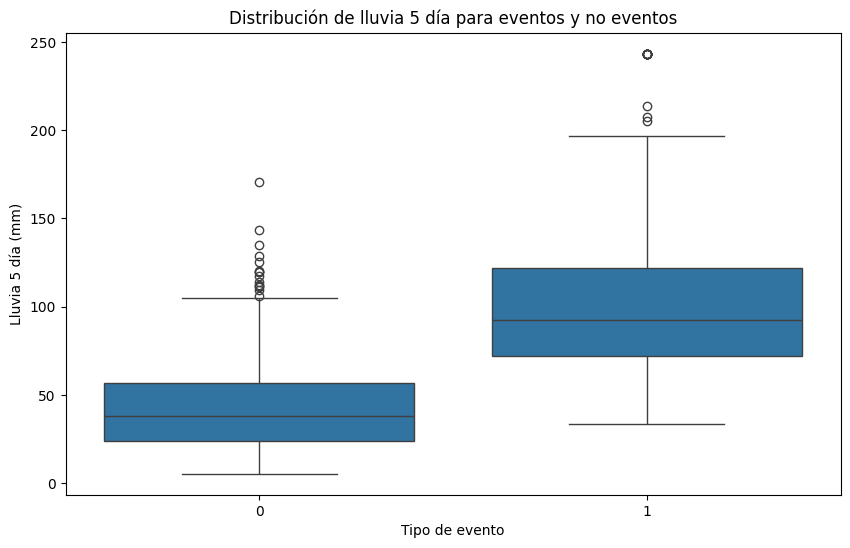

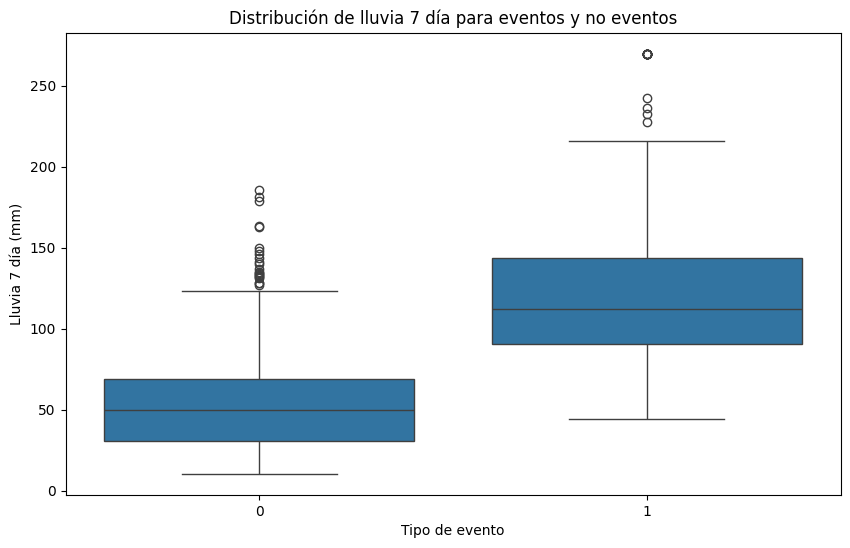

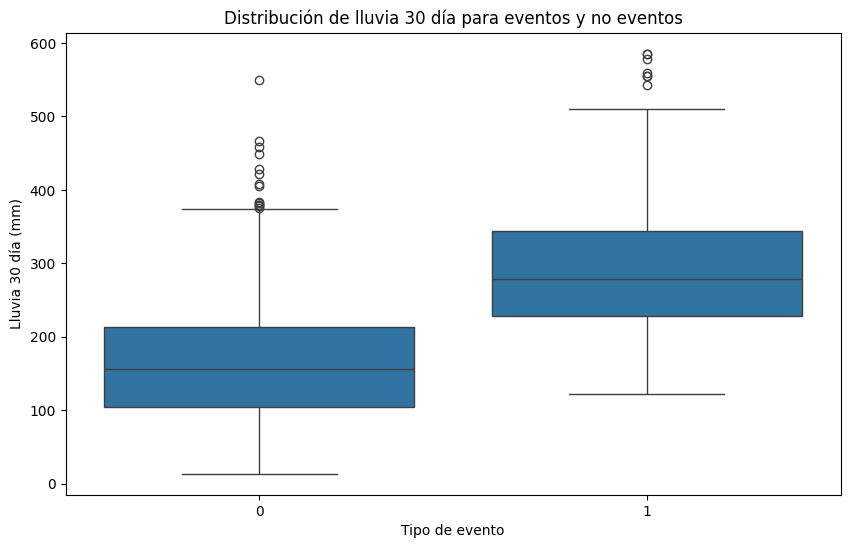

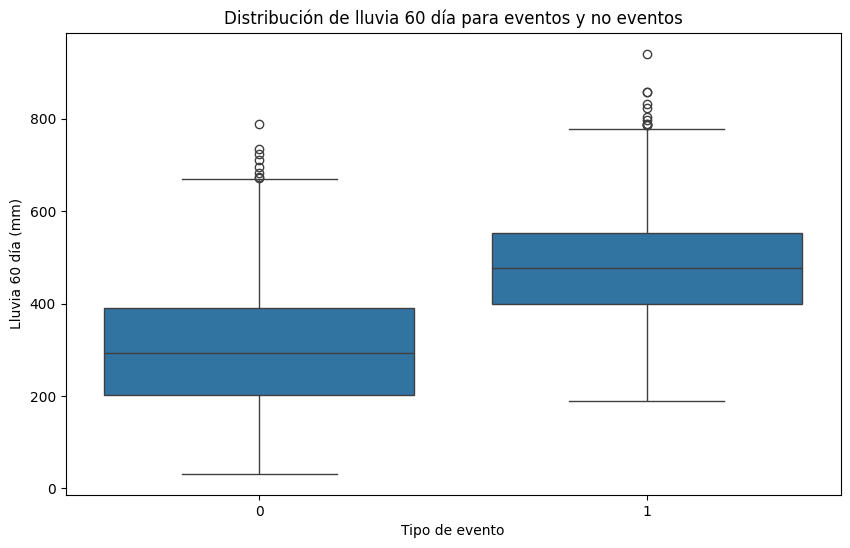

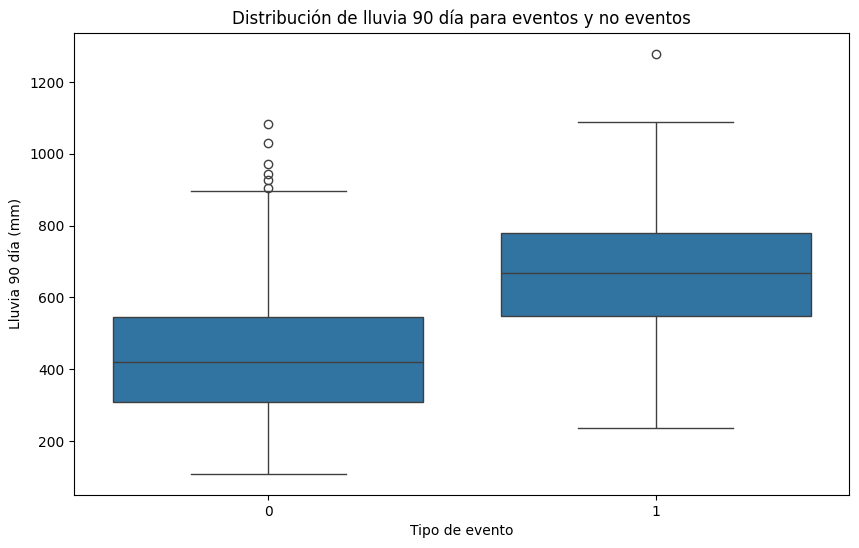

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_combined = pd.read_csv('/home/oisanchezp/Thesis/data/processed/slope_units_si_no_20251115.csv')
df_si = pd.read_csv('/home/oisanchezp/Thesis/data/processed/slope_units_si_no_20251115.csv')
#hacer un grafico de la lluvia de 1 día para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='1d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 1 día para eventos y no eventos')
plt.xlabel('Lluvia 1 día (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='3d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 3 días para eventos y no eventos')
plt.xlabel('Lluvia 3 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_7d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='5d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 5 días para eventos y no eventos')
plt.xlabel('Lluvia 5 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_7d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

#hacer un grafico de la lluvia de 7 días para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='7d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 7 días para eventos y no eventos')
plt.xlabel('Lluvia 7 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_7d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

#Hacer un grafico de la lluvia de 90 días para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='31d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 30 días para eventos y no eventos')
plt.xlabel('Lluvia 30 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_90d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

#Hacer un grafico de la lluvia de 90 días para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='61d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 60 días para eventos y no eventos')
plt.xlabel('Lluvia 60 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_90d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

#Hacer un grafico de la lluvia de 90 días para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='91d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 90 días para eventos y no eventos')
plt.xlabel('Lluvia 90 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_90d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()


#hacer un bloxplot de la lluvia de 1 día para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='1d')
plt.title('Distribución de lluvia 1 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 1 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='3d')
plt.title('Distribución de lluvia 3 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 3 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='5d')
plt.title('Distribución de lluvia 5 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 5 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='7d')
plt.title('Distribución de lluvia 7 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 7 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='30d')
plt.title('Distribución de lluvia 30 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 30 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='60d')
plt.title('Distribución de lluvia 60 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 60 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='90d')
plt.title('Distribución de lluvia 90 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 90 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

### **ENSAYAMOS MODELO GAM**



In [7]:
import pandas as pd
import numpy as np
from pygam import LogisticGAM, s
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Ruta a tu dataset combinado SI+NO
path = "/home/oisanchezp/Thesis/data/processed/slope_units_si_no_20251115.csv"
df = pd.read_csv(path)

# --- 1) Limpiar básico ---
df = df[df["si_no"].isin([0, 1])].copy()

# Variables
vars_lluvia = ["1d", "33d"]
#vars_topo   = ["geo_dom", "cobertura_dom", "slope_mean", "slope_std",
#               "aspect_mean", "aspect_std"]
vars_clima  = ["Mes", "ONI"]

#features = vars_lluvia + vars_topo + vars_clima
features = vars_lluvia + vars_clima

# Filtrar filas con NaN en estas columnas
df_model = df.dropna(subset=features + ["si_no"]).copy()

# --- convertir categóricas a numéricas ---
cat_cols = ["geo_dom"]
# si ENSO está como string, agrégala:
# cat_cols.append("ENSO")

for col in cat_cols:
    df_model[col] = df_model[col].astype("category").cat.codes

# Construir matrices
X = df_model[features].values.astype(float)
y = df_model["si_no"].values.astype(int)

print("N total usado en el modelo:", X.shape[0])

# --- 2) Train / test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- 3) Definir el GAM (un smooth por cada variable) ---
n_features = X_train.shape[1]

terms = s(0, n_splines=5)
for i in range(1, n_features):
    terms += s(i, n_splines=5)

gam = LogisticGAM(terms)
gam.gridsearch(X_train, y_train)

# --- 4) Predicciones y AUROC ---
y_prob_test = gam.predict_proba(X_test)  # prob de si_no = 1
auc = roc_auc_score(y_test, y_prob_test)

print(f"AUROC en test: {auc:.3f}")

gam.summary()


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00


N total usado en el modelo: 1369


 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


AUROC en test: 0.987
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     13.4581
Link Function:                        LogitLink Log Likelihood:                                  -133.9492
Number of Samples:                          958 AIC:                                              294.8146
                                                AICc:                                             295.2888
                                                UBRE:                                                2.319
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.7805
Feature Function

/tmp/ipykernel_3323422/3832887070.py:61: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


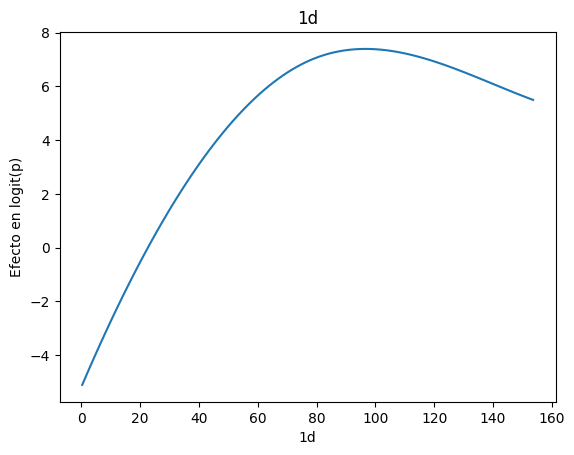

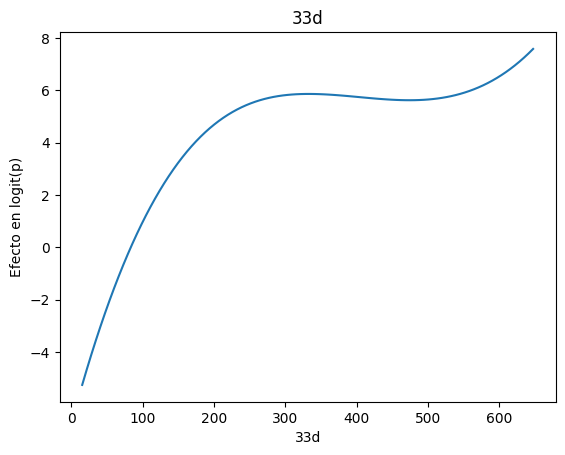

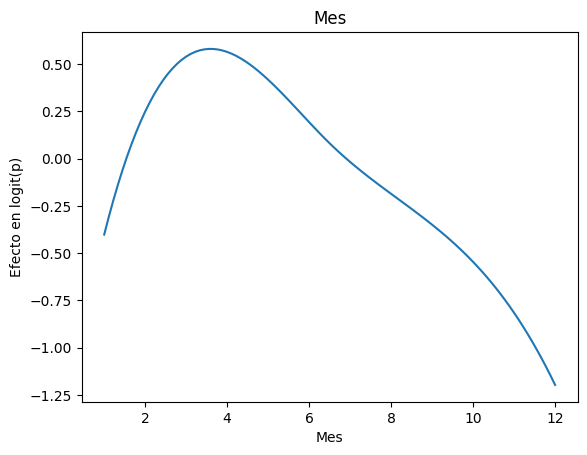

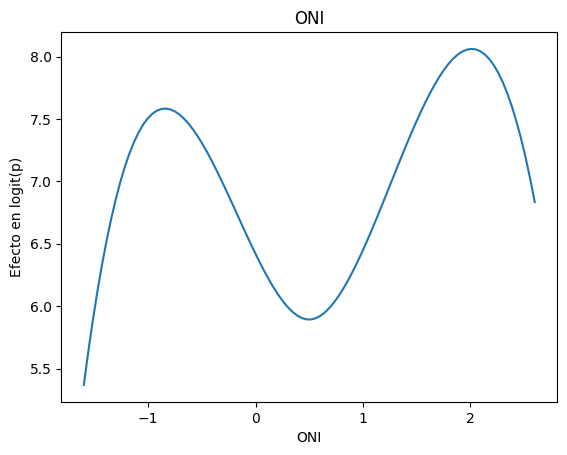

In [8]:
import matplotlib.pyplot as plt
import numpy as np

for i, var in enumerate(features):
    XX = gam.generate_X_grid(term=i)
    plt.figure()
    plt.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    plt.title(var)
    plt.xlabel(var)
    plt.ylabel("Efecto en logit(p)")
    plt.show()


### **ENSAYAMOS MODELO GAM CON VARIABLES CLIMÁTICAS Y ESCOGEMOS LA MEJOR COMBINACIÓN DE DÍAS DE CORTO Y LARGO PLAZO**

- Se corre en python bajo un script llamado "GAM_windowns_t_p.py" por que es demorado



In [11]:
import pandas as pd
import numpy as np

from pygam import LogisticGAM, s
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score

# -----------------------------
# 1. Cargar datos
# -----------------------------
path = "/home/oisanchezp/Thesis/data/processed/slope_units_si_no_20251115.csv"
df = pd.read_csv(path)

# Nos quedamos solo con filas válidas (si_no binario y sin NaN en Mes/ONI)
df = df[df["si_no"].isin([0, 1])].copy()
df = df.dropna(subset=["Mes", "ONI", "si_no"])

# Opcional: asegurar tipos
df["Mes"] = df["Mes"].astype(int)
df["si_no"] = df["si_no"].astype(int)

# -----------------------------
# 2. Función para construir T y P
# -----------------------------
def build_TP_dataset(df, t_days, p_days, max_days=90):
    """
    t_days: longitud de la ventana de corto plazo T (1-7).
    p_days: longitud de la ventana de largo plazo P (8-90).
    max_days: máximo acumulado disponible en el DataFrame (90 por defecto).

    Asumimos columnas "1d", "2d", ..., "90d" que son acumulados de k días.
    T = R_t
    P = R_{t+p} - R_t
    """
    total_days = t_days + p_days
    if total_days > max_days:
        return None, None  # combinación imposible con las columnas disponibles

    col_T = f"{t_days}d"
    col_tot = f"{total_days}d"

    needed_cols = [col_T, col_tot, "Mes", "ONI", "si_no"]
    for c in needed_cols:
        if c not in df.columns:
            print(f"Falta la columna {c} en el DataFrame. Ajusta los nombres.")
            return None, None

    sub = df.dropna(subset=needed_cols).copy()
    if sub.empty:
        return None, None

    # Construir T y P
    T_vals = sub[col_T].values
    P_vals = sub[col_tot].values - sub[col_T].values

    # Matriz de predictores: [T, P, Mes, ONI]
    X = np.column_stack([T_vals,
                         P_vals,
                         sub["Mes"].values.astype(float),
                         sub["ONI"].values.astype(float)])
    y = sub["si_no"].values.astype(int)

    return X, y

# -----------------------------
# 3. Función para evaluar un par (T,P) con CV
# -----------------------------
def evaluate_TP_with_cv(df, t_days, p_days,
                        n_splits=10, n_repeats=10, random_state=42):
    """
    Devuelve lista de AUROC para la combinación (t_days, p_days)
    usando RepeatedStratifiedKFold.
    """
    X, y = build_TP_dataset(df, t_days, p_days)
    if X is None or y is None or len(np.unique(y)) < 2:
        # No hay datos suficientes o solo una clase
        return None, 0

    # Definimos términos del GAM:
    # 0: T (corto plazo)
    # 1: P (largo plazo)
    # 2: Mes
    # 3: ONI
    terms = s(0) + s(1) + s(2) + s(3)

    rkf = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )

    aucs = []

    for train_idx, test_idx in rkf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        gam = LogisticGAM(terms)

        # pequeña malla de lambdas para que no sea eterno
        # (puedes refinarla luego)
        gam.gridsearch(
            X_train,
            y_train,
            progress=False,
            lam=np.logspace(-2, 2, 5)
        )

        y_prob = gam.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_prob)
        aucs.append(auc)

    return np.array(aucs), len(y)

# -----------------------------
# 4. Loop sobre todas las combinaciones T, P
# -----------------------------
results = []

max_days = 90  # máximo acumulado que tienes en columnas "kd"

short_terms = range(1, 8)   # T = 1..7 días
long_terms  = range(8, 91)  # P = 8..90 días

for t in short_terms:
    for p in long_terms:
        if t + p > max_days:
            continue  # no se puede construir P con las columnas existentes

        print(f"Probando T={t} días, P={p} días...")
        aucs, n_obs = evaluate_TP_with_cv(df, t, p)
        if aucs is None:
            print(f"   -> combinación T={t}, P={p} sin datos suficientes.")
            continue

        results.append({
            "T_days": t,
            "P_days": p,
            "n_obs": n_obs,
            "median_auc": np.median(aucs),
            "mean_auc": np.mean(aucs),
            "std_auc": np.std(aucs)
        })

# -----------------------------
# 5. Resultados finales
# -----------------------------
res_df = pd.DataFrame(results)

# Ordenar de mejor a peor según mediana de AUROC
res_df = res_df.sort_values(by="median_auc", ascending=False)

# Ver las 10 mejores combinaciones
print(res_df.head(10))

# Guardar resultados
out_path = "/home/oisanchezp/Thesis/data/processed/resultados_TP_gam_10x10.csv"
res_df.to_csv(out_path, index=False)
print(f"Resultados guardados en: {out_path}")


Probando T=1 días, P=8 días...


/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multi

Probando T=1 días, P=9 días...


/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multi

Probando T=1 días, P=10 días...


...

Probando T=1 días, P=11 días...


/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multi

Probando T=1 días, P=12 días...


/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/home/oisanchezp/geo_env/lib/python3.8/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multi

KeyboardInterrupt: 

### **MAPA DE CALOR CON LA COMBINACIÓN DE DÍAS DE CORTO Y LARGO PLAZO**

- Esto para mirar cuales son las mejores combinaciones de días de corto y largo plazo


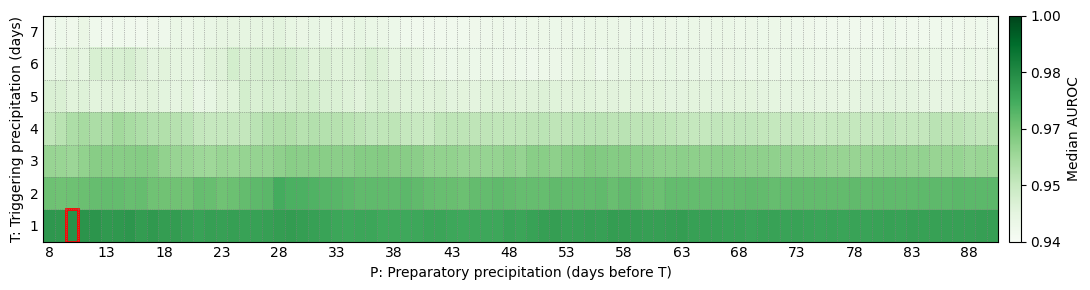

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1. Cargar datos
#df = pd.read_csv("/home/oisanchezp/Thesis/data/processed/resultados_TP_gam_10x10_2.csv")
df = pd.read_csv("/home/oisanchezp/Thesis/data/processed/resultados_TP_gam_10x3_2.csv")
# 2. Matriz T x P con el AUROC mediano
mat = df.pivot(index="T_days", columns="P_days", values="median_auc")

# 3. Par T–P con mejor AUROC
best = df.loc[df["median_auc"].idxmax()]

# límites de P y T
x_min, x_max = mat.columns.min(), mat.columns.max()
y_min, y_max = mat.index.min(),  mat.index.max()

# 4. Gráfico tipo heatmap
fig, ax = plt.subplots(figsize=(12, 3))

vmin, vmax = 0.94, 1.00

im = ax.imshow(
    mat.values,
    origin="lower",
    aspect="auto",
    cmap="Greens",
    extent=[x_min - 0.5, x_max + 0.5, y_min - 0.5, y_max + 0.5],
    vmin=vmin,          # límite inferior del mapa de colores
    vmax=vmax           # límite superior
)

# Ejes
ax.set_xlabel("P: Preparatory precipitation (days before T)")
ax.set_ylabel("T: Triggering precipitation (days)")

# límites de P y T
x_min, x_max = mat.columns.min(), mat.columns.max()
y_min, y_max = mat.index.min(),  mat.index.max()

# Etiquetas (ticks mayores) -> centros de celdas
ax.set_xticks(np.arange(x_min, x_max + 1, 5))   # cada 5 días en P
ax.set_yticks(np.arange(y_min, y_max + 1, 1))   # cada 1 día en T

# Ticks menores -> bordes de las celdas
ax.set_xticks(np.arange(x_min - 0.5, x_max + 0.5 + 1, 1), minor=True)
ax.set_yticks(np.arange(y_min - 0.5, y_max + 0.5 + 1, 1), minor=True)

# Grilla gris punteada en los ticks menores (bordes)
ax.grid(which="minor", color="grey", linestyle=":", linewidth=0.5)

# Sin rayitas de ticks
ax.tick_params(which="both", length=0)

# Colorbar más pegada
cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("Median AUROC")

# 5 ticks entre 0.90 y 1.00
ticks = np.linspace(vmin, vmax, 5)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])  # 3 decimales, por ejemplo


# 5. Recuadro rojo en el mejor par T–P
ax.add_patch(
    Rectangle(
        (best["P_days"] - 0.5, best["T_days"] - 0.5),
        1, 1,
        fill=False,
        edgecolor="red",
        linewidth=2
    )
)

plt.tight_layout()
plt.show()


In [35]:
#cual es la combinacion con mejor auc
best_row = df.loc[df['median_auc'].idxmax()]
best_T = best_row['T_days']
best_P = best_row['P_days']

#sacar los 10 mejores valores de median_auc
top_10 = df.nlargest(10, 'median_auc')
print("Top 10 combinaciones T-P según median_auc:")
print(top_10[['T_days', 'P_days', 'median_auc']])

Top 10 combinaciones T-P según median_auc:
   T_days  P_days  median_auc
0       1      10    0.983185
1       1      11    0.982825
2       1      12    0.982561
3       1      15    0.982203
4       1       8    0.982102
5       1       9    0.981944
6       1      14    0.981830
7       1      13    0.981605
8       1      17    0.981486
9       1      16    0.981008


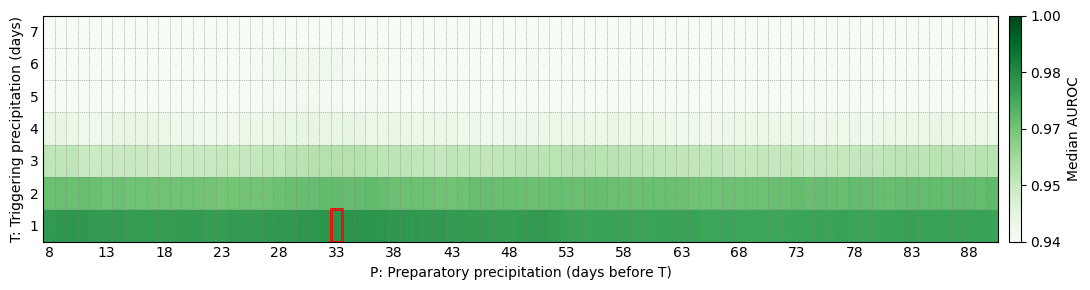

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1. Cargar datos
df = pd.read_csv("/home/oisanchezp/Thesis/data/processed/resultados_TP_gam_5x5.csv")

# 2. Matriz T x P con el AUROC mediano
mat = df.pivot(index="T_days", columns="P_days", values="median_auc")

# 3. Par T–P con mejor AUROC
best = df.loc[df["median_auc"].idxmax()]

# límites de P y T
x_min, x_max = mat.columns.min(), mat.columns.max()
y_min, y_max = mat.index.min(),  mat.index.max()

# 4. Gráfico tipo heatmap
fig, ax = plt.subplots(figsize=(12, 3))

vmin, vmax = 0.94, 1.00

im = ax.imshow(
    mat.values,
    origin="lower",
    aspect="auto",
    cmap="Greens",
    extent=[x_min - 0.5, x_max + 0.5, y_min - 0.5, y_max + 0.5],
    vmin=vmin,          # límite inferior del mapa de colores
    vmax=vmax           # límite superior
)
# Ejes
ax.set_xlabel("P: Preparatory precipitation (days before T)")
ax.set_ylabel("T: Triggering precipitation (days)")

# límites de P y T
x_min, x_max = mat.columns.min(), mat.columns.max()
y_min, y_max = mat.index.min(),  mat.index.max()

# Etiquetas (ticks mayores) -> centros de celdas
ax.set_xticks(np.arange(x_min, x_max + 1, 5))   # cada 5 días en P
ax.set_yticks(np.arange(y_min, y_max + 1, 1))   # cada 1 día en T

# Ticks menores -> bordes de las celdas
ax.set_xticks(np.arange(x_min - 0.5, x_max + 0.5 + 1, 1), minor=True)
ax.set_yticks(np.arange(y_min - 0.5, y_max + 0.5 + 1, 1), minor=True)

# Grilla gris punteada en los ticks menores (bordes)
ax.grid(which="minor", color="grey", linestyle=":", linewidth=0.5)

# Sin rayitas de ticks
ax.tick_params(which="both", length=0)

# Colorbar más pegada
cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("Median AUROC")

# 5 ticks entre 0.90 y 1.00
ticks = np.linspace(vmin, vmax, 5)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])  # 3 decimales, por ejemplo

# 5. Recuadro rojo en el mejor par T–P
ax.add_patch(
    Rectangle(
        (best["P_days"] - 0.5, best["T_days"] - 0.5),
        1, 1,
        fill=False,
        edgecolor="red",
        linewidth=2
    )
)

plt.tight_layout()
plt.show()


In [20]:
#cual es la combinacion con mejor auc
best_row = df.loc[df['median_auc'].idxmax()]
best_T = best_row['T_days']
best_P = best_row['P_days']

#sacar los 10 mejores valores de mean_auc
top_10 = df.nlargest(10, 'median_auc')
print("Top 10 combinaciones T-P según median_auc:")
print(top_10[['T_days', 'P_days', 'median_auc']])

Top 10 combinaciones T-P según median_auc:
   T_days  P_days  median_auc
0       1      33    0.982740
1       1      34    0.982680
2       1      36    0.982621
3       1      35    0.982611
4       1      32    0.982490
5       1      37    0.982203
6       1      10    0.982165
7       1      30    0.982128
8       1      31    0.982105
9       1       9    0.982045


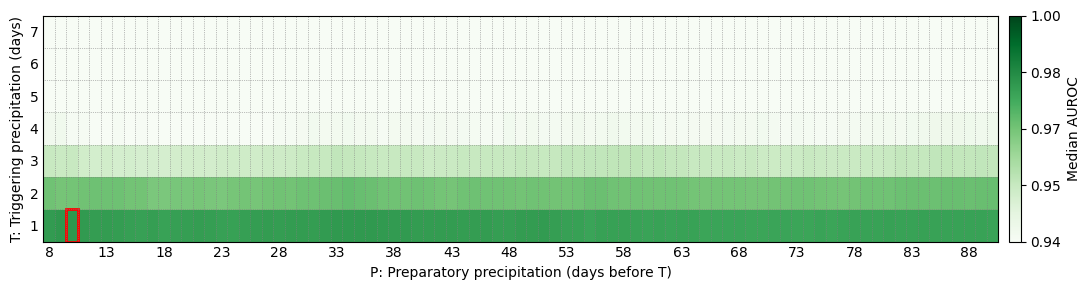

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1. Cargar datos
df = pd.read_csv("/home/oisanchezp/Thesis/data/processed/resultados_TP_logit_5x5.csv")

# 2. Matriz T x P con el AUROC mediano
mat = df.pivot(index="T_days", columns="P_days", values="median_auc")

# 3. Par T–P con mejor AUROC
best = df.loc[df["median_auc"].idxmax()]

# límites de P y T
x_min, x_max = mat.columns.min(), mat.columns.max()
y_min, y_max = mat.index.min(),  mat.index.max()

# 4. Gráfico tipo heatmap
fig, ax = plt.subplots(figsize=(12, 3))

vmin, vmax = 0.94, 1.00

im = ax.imshow(
    mat.values,
    origin="lower",
    aspect="auto",
    cmap="Greens",
    extent=[x_min - 0.5, x_max + 0.5, y_min - 0.5, y_max + 0.5],
    vmin=vmin,          # límite inferior del mapa de colores
    vmax=vmax           # límite superior
)

# Ejes
ax.set_xlabel("P: Preparatory precipitation (days before T)")
ax.set_ylabel("T: Triggering precipitation (days)")

# límites de P y T
x_min, x_max = mat.columns.min(), mat.columns.max()
y_min, y_max = mat.index.min(),  mat.index.max()

# Etiquetas (ticks mayores) -> centros de celdas
ax.set_xticks(np.arange(x_min, x_max + 1, 5))   # cada 5 días en P
ax.set_yticks(np.arange(y_min, y_max + 1, 1))   # cada 1 día en T

# Ticks menores -> bordes de las celdas
ax.set_xticks(np.arange(x_min - 0.5, x_max + 0.5 + 1, 1), minor=True)
ax.set_yticks(np.arange(y_min - 0.5, y_max + 0.5 + 1, 1), minor=True)

# Grilla gris punteada en los ticks menores (bordes)
ax.grid(which="minor", color="grey", linestyle=":", linewidth=0.5)

# Sin rayitas de ticks
ax.tick_params(which="both", length=0)

# Colorbar más pegada
cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("Median AUROC")


# 5 ticks entre 0.90 y 1.00
ticks = np.linspace(vmin, vmax, 5)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])  # 3 decimales, por ejemplo

# 5. Recuadro rojo en el mejor par T–P
ax.add_patch(
    Rectangle(
        (best["P_days"] - 0.5, best["T_days"] - 0.5),
        1, 1,
        fill=False,
        edgecolor="red",
        linewidth=2
    )
)

plt.tight_layout()
plt.show()


In [6]:
#cual es la combinacion con mejor auc
best_row = df.loc[df['median_auc'].idxmax()]
best_T = best_row['T_days']
best_P = best_row['P_days']

#sacar los 10 mejores valores de median_auc
top_10 = df.nlargest(10, 'median_auc')
print("Top 10 combinaciones T-P según median_auc:")
print(top_10[['T_days', 'P_days', 'median_auc']])

Top 10 combinaciones T-P según median_auc:
   T_days  P_days  median_auc
0       1      10    0.981947
1       1       9    0.981765
2       1      36    0.981645
3       1      33    0.981546
4       1      35    0.981546
5       1      34    0.981486
6       1      11    0.981426
7       1      37    0.981366
8       1      39    0.981282
9       1       8    0.981145


### **MONTECARLOS PARA ESCOGER LOS NO Y DENTRO CROSS VALIDATION PARA TODAS LAS COMBINACIONES DE LLUVIA DE CORTO Y LARGO PLAZO**

- Las corridas se hicieron en un archivo .py llamado "montecarlo.py"
- Los resultados se guardaron en "resultados_TP_GAM_montecarlo.csv"
- Analisis de sensbilidad para mirar la estabilidad de las combinaciones de días de corto y largo plazo con diferentes selecciones de no eventos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


all_results = pd.read_csv(
    "/home/oisanchezp/Thesis/data/processed/resultados_TP_GAM_montecarlo.csv"
)


sens_df = (
    all_results
    .groupby(["T_days", "P_days"])
    .agg(
        mean_auc_mc=("median_auc", "mean"),
        std_auc_mc=("median_auc", "std"),
        n_mc=("mc_id", "nunique")
    )
    .reset_index()
)


T_vals = sorted(sens_df["T_days"].unique())
P_vals = sorted(sens_df["P_days"].unique())

mean_mat = np.full((len(T_vals), len(P_vals)), np.nan)
std_mat  = np.full((len(T_vals), len(P_vals)), np.nan)

for i, t in enumerate(T_vals):
    for j, p in enumerate(P_vals):
        sub = sens_df[(sens_df["T_days"] == t) & (sens_df["P_days"] == p)]
        if len(sub) == 1:
            mean_mat[i, j] = sub["mean_auc_mc"].values[0]
            std_mat[i, j]  = sub["std_auc_mc"].values[0]


# 4) Encontrar la mejor combinación: max mean, y si empata, min std
best_row = (
    sens_df
    .sort_values(["mean_auc_mc", "std_auc_mc"], ascending=[False, True])
    .iloc[0]
)
best_T = best_row["T_days"]
best_P = best_row["P_days"]

# Índices de esa combinación en las matrices
i_best = T_vals.index(best_T)
j_best = P_vals.index(best_P)

print(f"Mejor combinación T={best_T} días, P={best_P} días")
print(f"AUROC medio = {best_row['mean_auc_mc']:.3f}, std = {best_row['std_auc_mc']:.3f}")


Mejor combinación T=1.0 días, P=33.0 días
AUROC medio = 0.979, std = 0.003


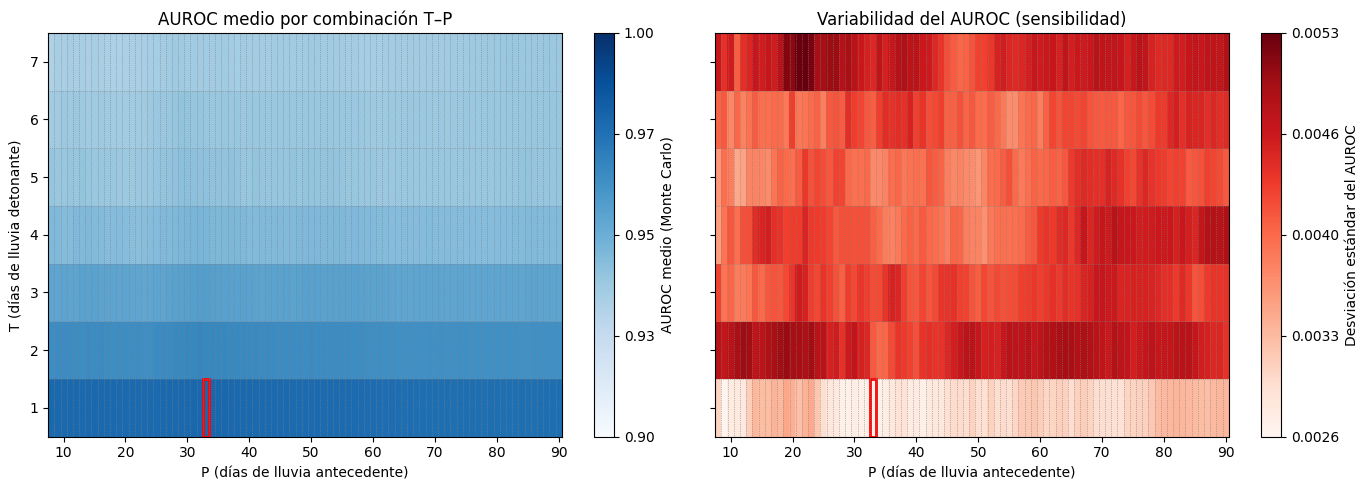

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# Indices de P donde P es múltiplo de 10 (10,20,...,90)
xticks_idx = [j for j, p in enumerate(P_vals) if p % 10 == 0]
xticks_lab = [P_vals[j] for j in xticks_idx]

# Para T puedes dejar todos (1..7) o también filtrar si quisieras
yticks_idx = np.arange(len(T_vals))
yticks_lab = T_vals



# 5) Graficar dos heatmaps con grilla y cuadro rojo
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ---------- PANEL 1: AUROC medio ----------
ax0 = axes[0]
im0 = ax0.imshow(
    mean_mat,
    origin="lower",
    aspect="auto",
    cmap="Blues",
    vmin=0.90,
    vmax=1.00
)

cbar0 = plt.colorbar(im0, ax=ax0)
ticks_mean = np.linspace(0.90, 1.00, 5)
cbar0.set_ticks(ticks_mean)
cbar0.set_ticklabels([f"{v:.2f}" for v in ticks_mean])
cbar0.set_label("AUROC medio (Monte Carlo)")

# Ticks usando solo P de 10 en 10
ax0.set_xticks(xticks_idx)
ax0.set_xticklabels(xticks_lab, rotation=0)

ax0.set_yticks(yticks_idx)
ax0.set_yticklabels(yticks_lab)

ax0.set_xlabel("P (días de lluvia antecedente)")
ax0.set_ylabel("T (días de lluvia detonante)")
ax0.set_title("AUROC medio por combinación T–P")

# Grilla gris punteada
ax0.set_xticks(np.arange(-0.5, len(P_vals), 1), minor=True)
ax0.set_yticks(np.arange(-0.5, len(T_vals), 1), minor=True)
ax0.grid(which="minor", color="gray", linestyle=":", linewidth=0.5)
ax0.tick_params(which="minor", bottom=False, left=False)

# Cuadro rojo alrededor de la mejor combinación
rect0 = Rectangle(
    (j_best - 0.5, i_best - 0.5),  # esquina inferior izquierda
    1, 1,                          # ancho y alto de la celda
    fill=False,
    edgecolor="red",
    linewidth=2
)
ax0.add_patch(rect0)


# ---------- PANEL 2: Desviación estándar ----------
ax1 = axes[1]
im1 = ax1.imshow(
    std_mat,
    origin="lower",
    aspect="auto",
    cmap="Reds",
)

cbar1 = plt.colorbar(im1, ax=ax1)
ticks_std = np.linspace(np.nanmin(std_mat), np.nanmax(std_mat), 5)
cbar1.set_ticks(ticks_std)
cbar1.set_ticklabels([f"{v:.4f}" for v in ticks_std])
cbar1.set_label("Desviación estándar del AUROC")

ax1.set_xticks(xticks_idx)
ax1.set_xticklabels(xticks_lab, rotation=0)

ax1.set_yticks(yticks_idx)
ax1.set_yticklabels(yticks_lab)

ax1.set_xlabel("P (días de lluvia antecedente)")
ax1.set_title("Variabilidad del AUROC (sensibilidad)")

ax1.set_xticks(np.arange(-0.5, len(P_vals), 1), minor=True)
ax1.set_yticks(np.arange(-0.5, len(T_vals), 1), minor=True)
ax1.grid(which="minor", color="gray", linestyle=":", linewidth=0.5)
ax1.tick_params(which="minor", bottom=False, left=False)


# Cuadro rojo en el mismo T,P
rect1 = Rectangle(
    (j_best - 0.5, i_best - 0.5),
    1, 1,
    fill=False,
    edgecolor="red",
    linewidth=2
)
ax1.add_patch(rect1)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

all_results = pd.read_csv(
    "/home/oisanchezp/Thesis/data/processed/resultados_TP_GAM_montecarlo.csv"
)

# 1) Para cada corrida Monte Carlo, elegir el (T,P) con mayor AUROC
best_per_mc = (
    all_results
    .sort_values(["mc_id", "median_auc"], ascending=[True, False])
    .groupby("mc_id")
    .head(1)   # el mejor de cada mc_id
)

# 2) Contar cuántas veces gana cada combinación (T,P)
win_counts = (
    best_per_mc
    .groupby(["T_days", "P_days"])
    .size()
    .reset_index(name="n_wins")
)

# 3) Calcular porcentaje de victorias
n_mc = best_per_mc["mc_id"].nunique()
win_counts["win_pct"] = 100 * win_counts["n_wins"] / n_mc

# 4) Ordenar de más a menos ganador
win_counts = win_counts.sort_values(["n_wins", "T_days", "P_days"],
                                    ascending=[False, True, True])

print(win_counts.head(10))


    T_days  P_days  n_wins  win_pct
0        1       8       3     15.0
4        1      17       3     15.0
8        1      33       2     10.0
10       1      35       2     10.0
11       1      37       2     10.0
1        1       9       1      5.0
2        1      15       1      5.0
3        1      16       1      5.0
5        1      19       1      5.0
6        1      29       1      5.0


In [4]:
# 1) Cargar resultados Monte Carlo
all_results = pd.read_csv(
    "/home/oisanchezp/Thesis/data/processed/GAM_MC_summary_T1-7_P8-90.csv"
)

all_results.head()

,T_days,P_days,auc,auc.1,auc.2,ap,ap.1,ap.2,f1,f1.1,...,recall.2,precision,precision.1,precision.2,pofd,pofd.1,pofd.2,hk,hk.1,hk.2
0,NaN,NaN,mean,median,std,mean,median,std,mean,median,...,std,mean,median,std,mean,median,std,mean,median,std
1,1.0,8.0,0.9751266198391086,0.9755923419057455,0.0036418836544860494,0.9565624829304078,0.9557384889045435,0.007108239145330757,0.9034467353744745,0.906715119112262,...,0.009943864368935622,0.9181233784421119,0.9275058275058274,0.03311342971866487,0.041593977488170605,0.03571428571428571,0.018853198727568743,0.8484303534120727,0.851142870447519,0.013538871467354935
2,1.0,9.0,0.9752559225573046,0.9752979320830104,0.0036445604238652205,0.9565322959140052,0.9550657393529796,0.0071431341560870745,0.9049883189546775,0.9087390761548064,...,0.010680872712778044,0.9219633919915561,0.9277906304222094,0.02977095399646459,0.0393381691880056,0.035643884993382335,0.016687245247943436,0.8499615240310783,0.8531750535928408,0.012341502941347273
3,1.0,10.0,0.9755155154554295,0.9750683090993204,0.003907789241072064,0.9566953702385333,0.9550727535450166,0.0076490523769356085,0.9044819953449516,0.903698419666374,...,0.01250214906057449,0.9225284946943896,0.9269483401384697,0.02894068816954389,0.03896370087760698,0.03571428571428571,0.016381917929579336,0.8488708490007385,0.8457517799142849,0.011634516331854552
4,1.0,11.0,0.9750720833323975,0.9745613824504321,0.003902632825480397,0.9563908758123899,0.9550483480141654,0.007650300041747881,0.9036742122446031,0.9020419878628834,...,0.013445176198461823,0.9225093623531586,0.9266758110687023,0.030133431119144554,0.0389777921259284,0.035707723835771324,0.01695642872573991,0.8473969037378186,0.8438578405203454,0.011743559050404641


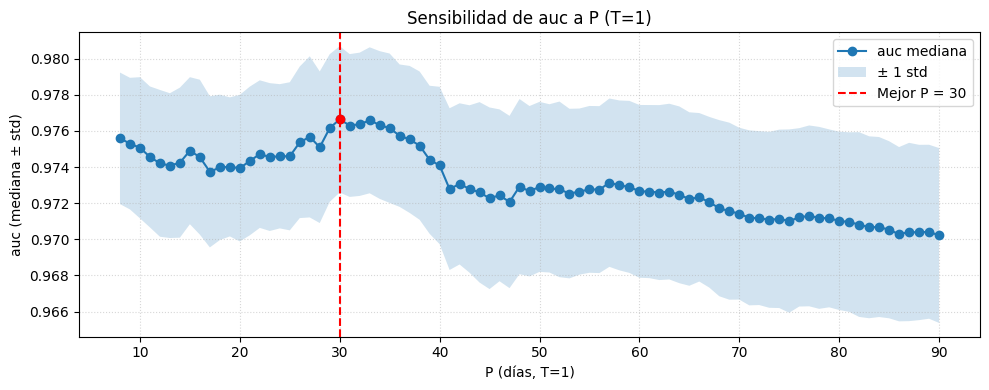

[auc] Mejor P (T=1): P=30, mediana=0.977, std=0.004


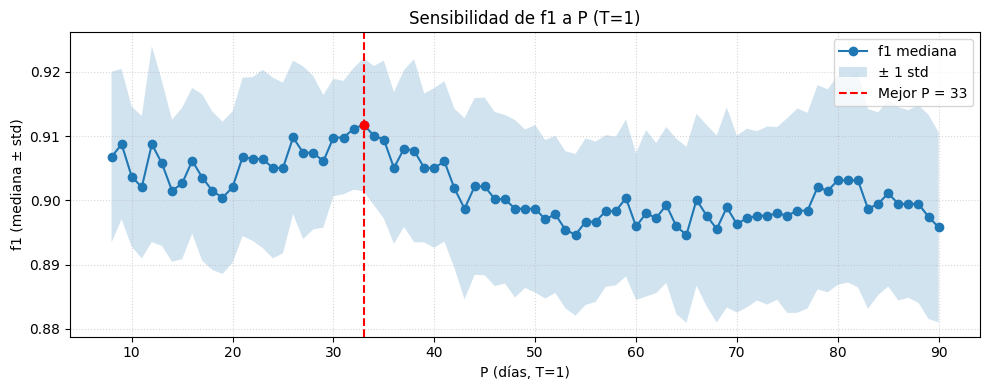

[f1] Mejor P (T=1): P=33, mediana=0.912, std=0.010


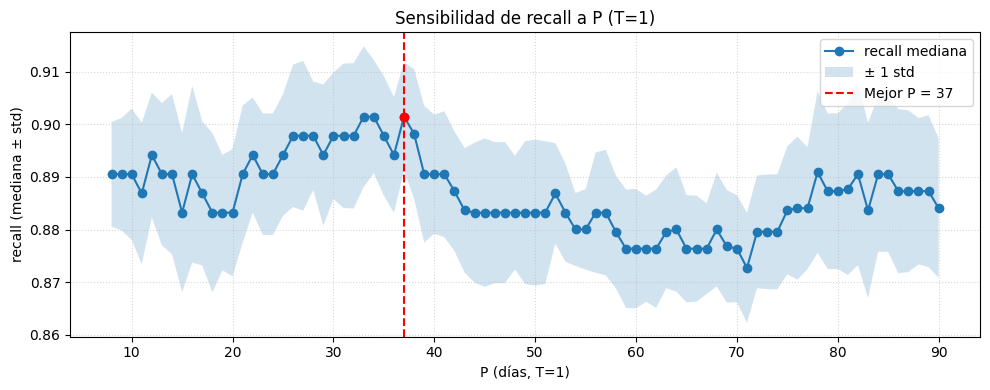

[recall] Mejor P (T=1): P=37, mediana=0.901, std=0.010


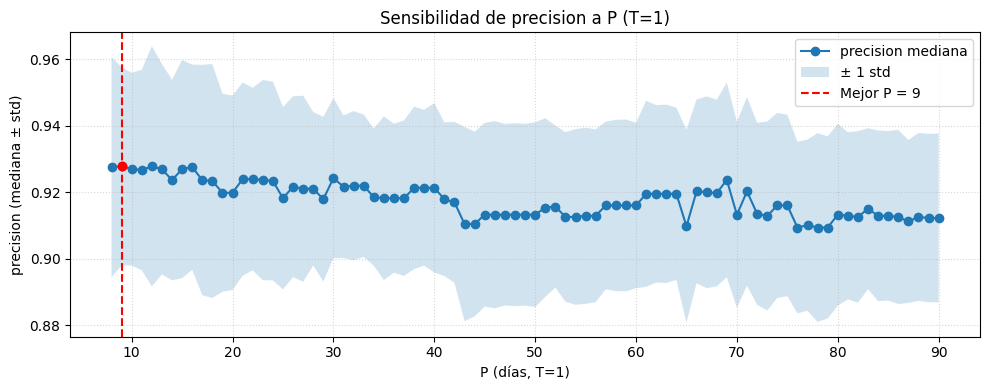

[precision] Mejor P (T=1): P=9, mediana=0.928, std=0.030


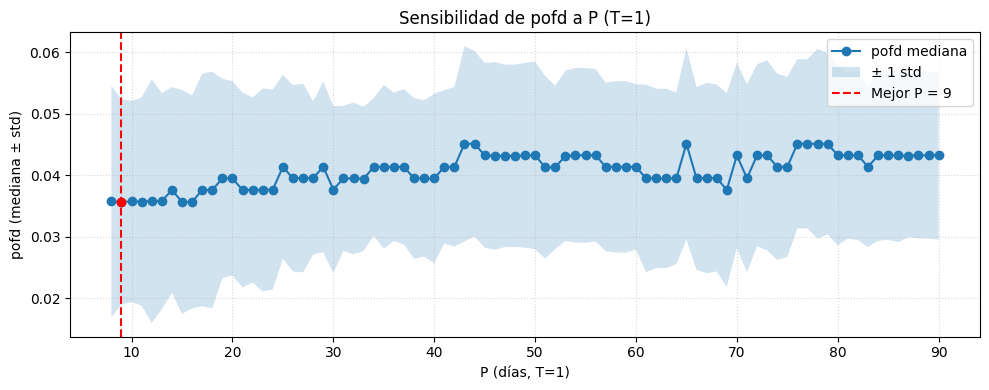

[pofd] Mejor P (T=1): P=9, mediana=0.036, std=0.017


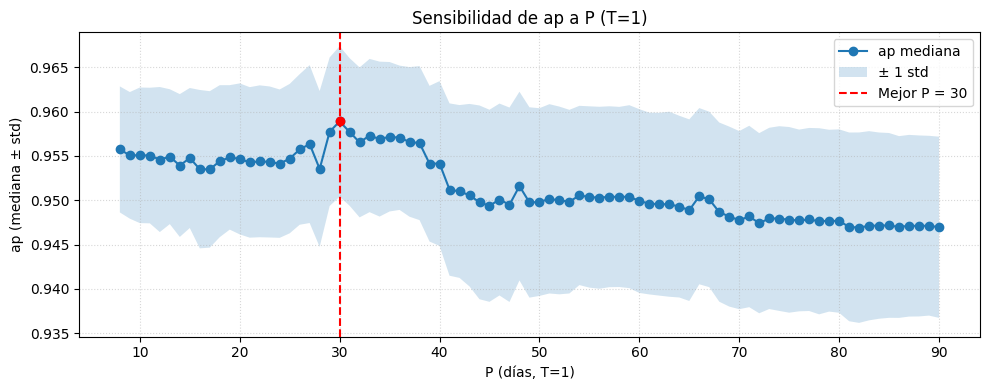

[ap] Mejor P (T=1): P=30, mediana=0.959, std=0.008


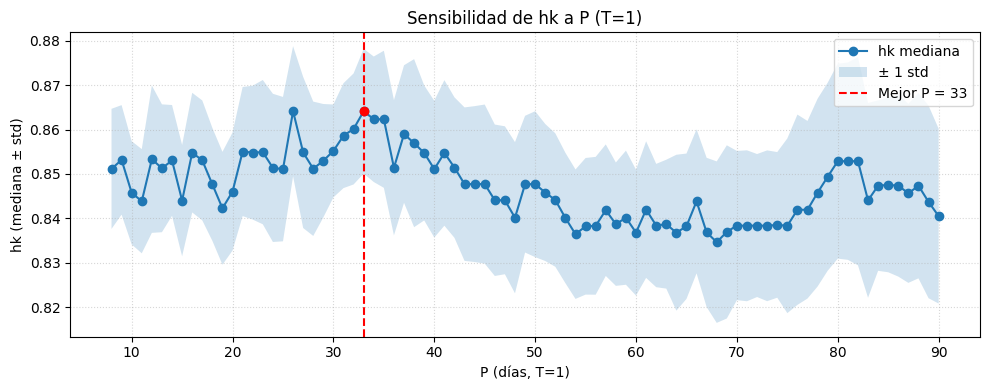

[hk] Mejor P (T=1): P=33, mediana=0.864, std=0.014


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Cargar y limpiar (tu CSV resumido)
# ------------------------------------------------------------
all_results = pd.read_csv(
    "/home/oisanchezp/Thesis/data/processed/GAM_MC_summary_T1-7_P8-90.csv"
)

# quitar fila 0 (la que trae 'mean/median/std' como texto)
all_results = all_results.dropna(subset=["T_days", "P_days"]).copy()

# convertir a numérico todo lo que se pueda (dejamos fuera columnas no numéricas)
for c in all_results.columns:
    all_results[c] = pd.to_numeric(all_results[c], errors="ignore")


# ------------------------------------------------------------
# 2) Función: curva P vs métrica (MEDIANA ± STD) para un T fijo
#    - mode="max": elige P con mayor mediana (auc, f1, recall, precision, ap, hk)
#    - mode="min": elige P con menor mediana (pofd)
# ------------------------------------------------------------
def plot_metric_curve_by_P(
    df,
    metric,                # e.g. "auc", "f1", "recall", "precision", "pofd", "ap", "hk"
    T=1,
    mode="max",            # "max" o "min" para escoger mejor P
    xlabel=None,
    ylabel=None,
    title=None,
    xtick_step=10
):
    # Mapear columnas (en tu tabla: metric=mean, metric.1=median, metric.2=std)
    col_mean = metric
    col_med  = f"{metric}.1"
    col_std  = f"{metric}.2"

    missing = [c for c in [col_med, col_std] if c not in df.columns]
    if missing:
        raise ValueError(f"No encuentro columnas para '{metric}': faltan {missing}")

    sub = df[df["T_days"] == T].copy()
    sub = sub.dropna(subset=["P_days", col_med, col_std])
    sub["P_days"] = pd.to_numeric(sub["P_days"], errors="coerce")
    sub[col_med]  = pd.to_numeric(sub[col_med],  errors="coerce")
    sub[col_std]  = pd.to_numeric(sub[col_std],  errors="coerce")
    sub = sub.dropna(subset=["P_days", col_med, col_std])

    curve = (
        sub[["P_days", col_med, col_std]]
        .rename(columns={col_med: "median_mc", col_std: "std_mc"})
        .sort_values("P_days")
        .reset_index(drop=True)
    )

    # elegir mejor P
    if mode == "max":
        best = curve.sort_values(["median_mc", "std_mc"], ascending=[False, True]).iloc[0]
    elif mode == "min":
        best = curve.sort_values(["median_mc", "std_mc"], ascending=[True,  True]).iloc[0]
    else:
        raise ValueError("mode debe ser 'max' o 'min'")

    best_P   = float(best["P_days"])
    best_med = float(best["median_mc"])
    best_std = float(best["std_mc"])

    # plot
    fig, ax = plt.subplots(figsize=(10, 4))

    x = curve["P_days"].values
    y = curve["median_mc"].values
    yerr = curve["std_mc"].values

    ax.plot(x, y, marker="o", linestyle="-", label=f"{metric} mediana")
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.2, label="± 1 std")

    ax.axvline(best_P, color="red", linestyle="--", linewidth=1.5,
               label=f"Mejor P = {best_P:.0f}")
    ax.scatter([best_P], [best_med], color="red", zorder=5)

    if xlabel is None:
        xlabel = f"P (días, T={T})"
    if ylabel is None:
        ylabel = f"{metric} (mediana ± std)"
    if title is None:
        title = f"Sensibilidad de {metric} a P (T={T})"

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # ticks
    p_max = int(np.nanmax(x))
    ax.set_xticks(np.arange(10, p_max + 1, xtick_step))

    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"[{metric}] Mejor P (T={T}): P={best_P:.0f}, mediana={best_med:.3f}, std={best_std:.3f}")


# ------------------------------------------------------------
# 3) Graficar para cada métrica (con mediana)
# ------------------------------------------------------------
# Nota: usa "mode=min" para pofd (queremos minimización de falsas alarmas)
metrics_to_plot = [
    ("auc",       "max"),
    ("f1",        "max"),
    ("recall",    "max"),
    ("precision", "max"),
    ("pofd",      "min"),
    # opcional si están en tu tabla:
    ("ap",        "max"),
    ("hk",        "max"),
]

for m, mode in metrics_to_plot:
    if m in all_results.columns or f"{m}.1" in all_results.columns:
        plot_metric_curve_by_P(all_results, metric=m, T=1, mode=mode)


Mejor P para T=1: P=31 días, AUROC medio=0.977, std=0.004


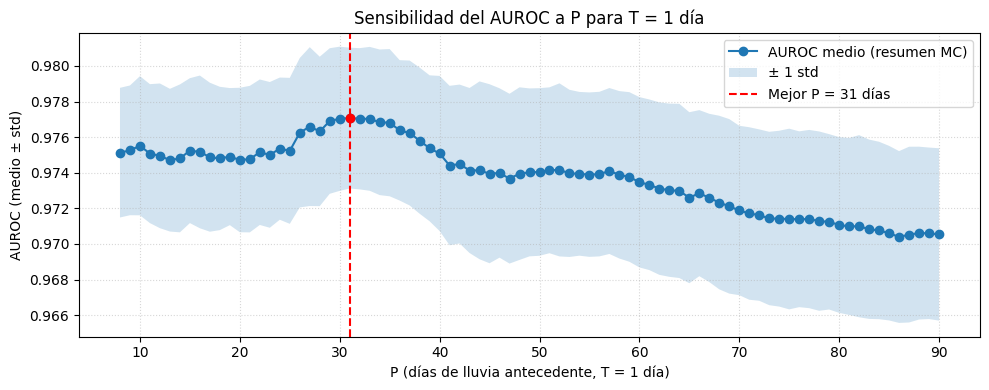

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Cargar y limpiar (tu CSV resumido)
# ------------------------------------------------------------
all_results = pd.read_csv(
    "/home/oisanchezp/Thesis/data/processed/GAM_MC_summary_T1-7_P8-90.csv"
)

# quitar fila 0 (la que trae 'mean/median/std' como texto)
all_results = all_results.dropna(subset=["T_days", "P_days"]).copy()

# convertir a numérico todo lo que se pueda (dejamos fuera columnas no numéricas)
for c in all_results.columns:
    all_results[c] = pd.to_numeric(all_results[c], errors="ignore")


# ------------------------------------------------------------
# 2) Función: curva P vs métrica (MEDIANA ± STD) para un T fijo
#    - mode="max": elige P con mayor mediana (auc, f1, recall, precision, ap, hk)
#    - mode="min": elige P con menor mediana (pofd)
# ------------------------------------------------------------
def plot_metric_curve_by_P(
    df,
    metric,                # e.g. "auc", "f1", "recall", "precision", "pofd", "ap", "hk"
    T=1,
    mode="max",            # "max" o "min" para escoger mejor P
    xlabel=None,
    ylabel=None,
    title=None,
    xtick_step=10
):
    # Mapear columnas (en tu tabla: metric=mean, metric.1=median, metric.2=std)
    col_mean = metric
    col_med  = f"{metric}.1"
    col_std  = f"{metric}.2"

    missing = [c for c in [col_med, col_std] if c not in df.columns]
    if missing:
        raise ValueError(f"No encuentro columnas para '{metric}': faltan {missing}")

    sub = df[df["T_days"] == T].copy()
    sub = sub.dropna(subset=["P_days", col_med, col_std])
    sub["P_days"] = pd.to_numeric(sub["P_days"], errors="coerce")
    sub[col_med]  = pd.to_numeric(sub[col_med],  errors="coerce")
    sub[col_std]  = pd.to_numeric(sub[col_std],  errors="coerce")
    sub = sub.dropna(subset=["P_days", col_med, col_std])

    curve = (
        sub[["P_days", col_med, col_std]]
        .rename(columns={col_med: "median_mc", col_std: "std_mc"})
        .sort_values("P_days")
        .reset_index(drop=True)
    )

    # elegir mejor P
    if mode == "max":
        best = curve.sort_values(["median_mc", "std_mc"], ascending=[False, True]).iloc[0]
    elif mode == "min":
        best = curve.sort_values(["median_mc", "std_mc"], ascending=[True,  True]).iloc[0]
    else:
        raise ValueError("mode debe ser 'max' o 'min'")

    best_P   = float(best["P_days"])
    best_med = float(best["median_mc"])
    best_std = float(best["std_mc"])

    # plot
    fig, ax = plt.subplots(figsize=(10, 4))

    x = curve["P_days"].values
    y = curve["median_mc"].values
    yerr = curve["std_mc"].values

    ax.plot(x, y, marker="o", linestyle="-", label=f"{metric} mediana")
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.2, label="± 1 std")

    ax.axvline(best_P, color="red", linestyle="--", linewidth=1.5,
               label=f"Mejor P = {best_P:.0f}")
    ax.scatter([best_P], [best_med], color="red", zorder=5)

    if xlabel is None:
        xlabel = f"P (días, T={T})"
    if ylabel is None:
        ylabel = f"{metric} (mediana ± std)"
    if title is None:
        title = f"Sensibilidad de {metric} a P (T={T})"

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # ticks
    p_max = int(np.nanmax(x))
    ax.set_xticks(np.arange(10, p_max + 1, xtick_step))

    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"[{metric}] Mejor P (T={T}): P={best_P:.0f}, mediana={best_med:.3f}, std={best_std:.3f}")


# ------------------------------------------------------------
# 3) Graficar para cada métrica (con mediana)
# ------------------------------------------------------------
# Nota: usa "mode=min" para pofd (queremos minimización de falsas alarmas)
metrics_to_plot = [
    ("auc",       "max"),
    ("f1",        "max"),
    ("recall",    "max"),
    ("precision", "max"),
    ("pofd",      "min"),
    # opcional si están en tu tabla:
    ("ap",        "max"),
    ("hk",        "max"),
]

for m, mode in metrics_to_plot:
    if m in all_results.columns or f"{m}.1" in all_results.columns:
        plot_metric_curve_by_P(all_results, metric=m, T=1, mode=mode)


   P_days  mean_auc_mc  std_auc_mc  n_mc
0       8     0.932399    0.004649    20
1       9     0.934047    0.004387    20
2      10     0.933883    0.004575    20
3      11     0.935029    0.004024    20
4      12     0.934102    0.004390    20
Mejor P para T=7: P=83.0 días, AUROC medio=0.938, std=0.005


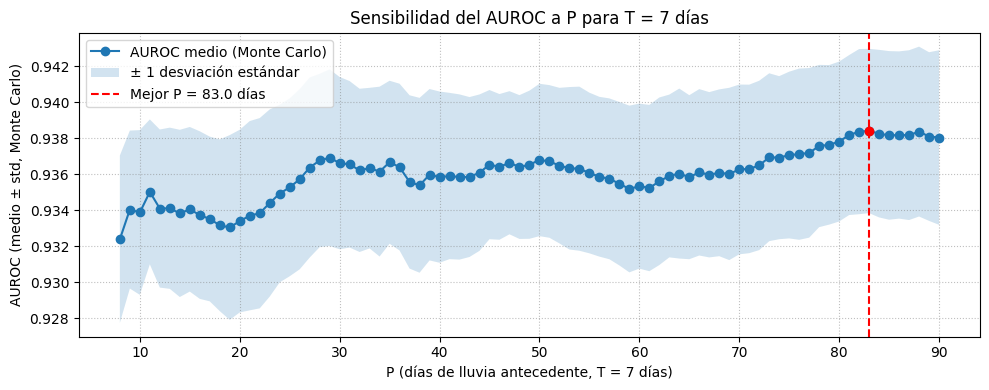

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Cargar resultados Monte Carlo
all_results = pd.read_csv(
    "/home/oisanchezp/Thesis/data/processed/resultados_TP_GAM_montecarlo.csv"
)

# 2) Filtrar solo T = 1 día
df_T1 = all_results[all_results["T_days"] == 7].copy()

# 3) Agrupar por P y sacar media, std y n corridas
curve = (
    df_T1
    .groupby("P_days")["median_auc"]
    .agg(mean_auc_mc="mean", std_auc_mc="std", n_mc="count")
    .reset_index()
)

print(curve.head())

# 4) Encontrar el mejor P según:
#    - mayor AUROC medio
#    - en empate, menor desviación estándar
best_row = (
    curve
    .sort_values(["mean_auc_mc", "std_auc_mc"], ascending=[False, True])
    .iloc[0]
)
best_P   = best_row["P_days"]
best_mu  = best_row["mean_auc_mc"]
best_std = best_row["std_auc_mc"]

print(f"Mejor P para T=7: P={best_P} días, AUROC medio={best_mu:.3f}, std={best_std:.3f}")

# 5) Graficar curva P vs AUROC medio ± std
fig, ax = plt.subplots(figsize=(10, 4))

# Ordenar por P por si acaso
curve = curve.sort_values("P_days")

x = curve["P_days"].values
y = curve["mean_auc_mc"].values
yerr = curve["std_auc_mc"].values

# Curva con bandas de incertidumbre
ax.plot(x, y, marker="o", linestyle="-", label="AUROC medio (Monte Carlo)")
ax.fill_between(x, y - yerr, y + yerr, alpha=0.2, label="± 1 desviación estándar")

# Línea vertical en el mejor P
ax.axvline(best_P, color="red", linestyle="--", linewidth=1.5,
           label=f"Mejor P = {best_P} días")

# Marcar explícitamente el punto óptimo
ax.scatter([best_P], [best_mu], color="red", zorder=5)

# Ejes y formato
ax.set_xlabel("P (días de lluvia antecedente, T = 7 días)")
ax.set_ylabel("AUROC (medio ± std, Monte Carlo)")
ax.set_title("Sensibilidad del AUROC a P para T = 7 días")

# Ticks del eje X cada 10 días (ajusta si quieres más resolución)
p_min, p_max = x.min(), x.max()
ax.set_xticks(np.arange(10, p_max + 1, 10))

ax.grid(True, linestyle=":", color="gray", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()


### **MONTECARLOS DE 50 CORRIDAS CON REGRESIÓN LOGISTICA - GAM - RANDOM FOREST**

- Con las variables de 1 días de corto plazo y 33 días de largo plazo y Mes y ENSO
- Las corridas se hicieron en un archivo .py llamado "montecarlo_GAM_Logit_RF.py"

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 0) CARGAR DATOS
# =========================
path = "/home/oisanchezp/Thesis/data/processed/resultados_1d_33d_GAM_Logit_RF_MC50.csv"  # <-- ajusta si es otro
df = pd.read_csv(path)

# (por si vienen con mayúsculas raras o espacios)
df.columns = [c.strip() for c in df.columns]

# métricas de interés
metrics = ["auc", "f1", "recall", "precision", "pofa"]
count_cols = ["tp", "tn", "fp", "fn"]

# =========================
# 1) TABLA RESUMEN (mean, median, sd, min, max)
# =========================
resumen = (
    df.groupby("modelo")[metrics]
      .agg(["mean", "median", "std", "min", "max"])
)

# aplanar columnas para que quede bonito
resumen.columns = [f"{m}_{stat}" for (m, stat) in resumen.columns]
resumen = resumen.reset_index()

print("\n=== RESUMEN MÉTRICAS (por modelo) ===")
print(resumen.to_string(index=False))

# # si quieres guardarla:
# out_resumen = "/home/oisanchezp/Thesis/data/processed/resumen_metricas_por_modelo.csv"
# resumen.to_csv(out_resumen, index=False)
# print(f"\nGuardado resumen en: {out_resumen}")


=== RESUMEN MÉTRICAS (por modelo) ===
      modelo  auc_mean  auc_median  auc_std  auc_min  auc_max  f1_mean  f1_median   f1_std   f1_min   f1_max  recall_mean  recall_median  recall_std  recall_min  recall_max  precision_mean  precision_median  precision_std  precision_min  precision_max  pofa_mean  pofa_median  pofa_std  pofa_min  pofa_max
         GAM  0.973370    0.973671 0.005505 0.957854 0.988357 0.899273   0.897945 0.014454 0.854015 0.947368     0.889328       0.890908    0.014390    0.847826    0.927536        0.909801          0.909433       0.023279       0.854167       0.984375   0.046114     0.045628  0.012946  0.007491  0.079545
       Logit  0.972383    0.972556 0.005438 0.960200 0.986511 0.893517   0.892472 0.013780 0.857143 0.928571     0.910390       0.909103    0.010340    0.891304    0.942029        0.877668          0.875431       0.025050       0.816993       0.925926   0.066364     0.067542  0.015470  0.037594  0.105660
RandomForest  0.977384    0.977577 0.004110

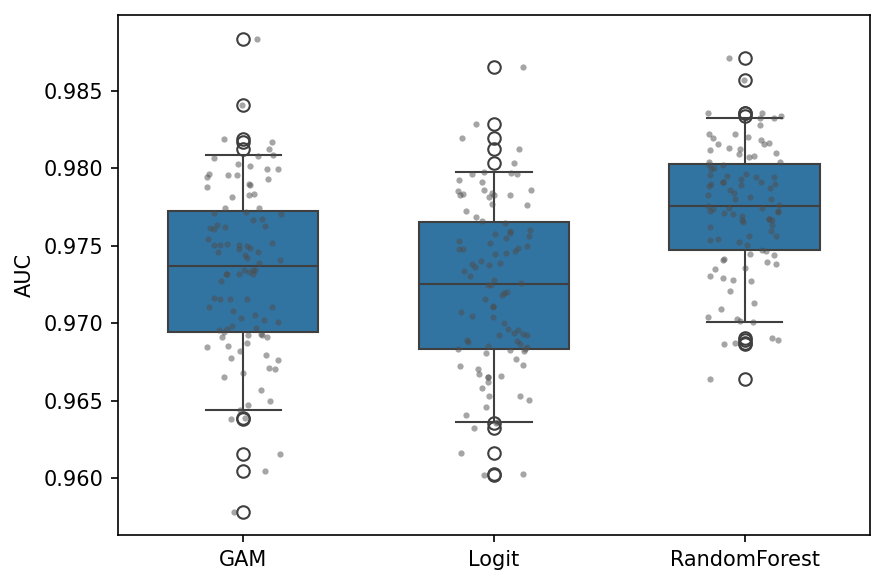

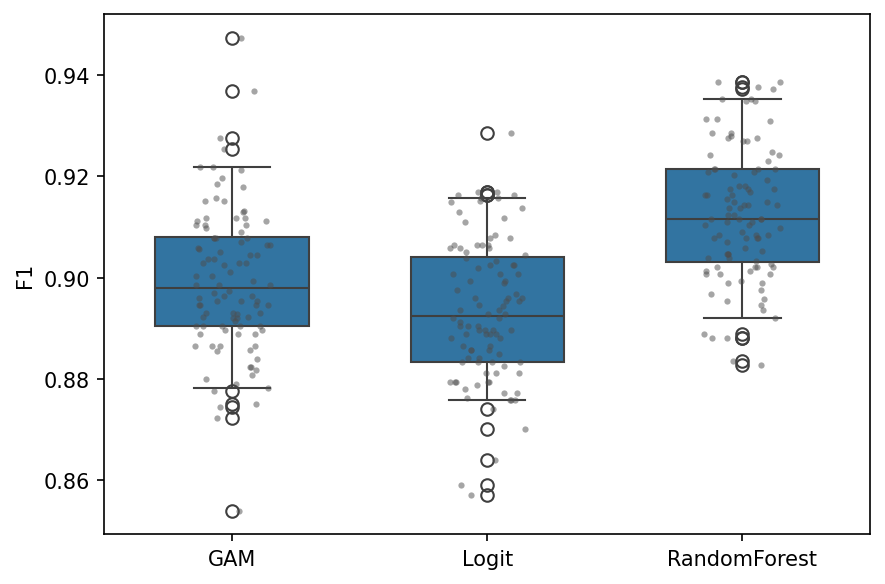

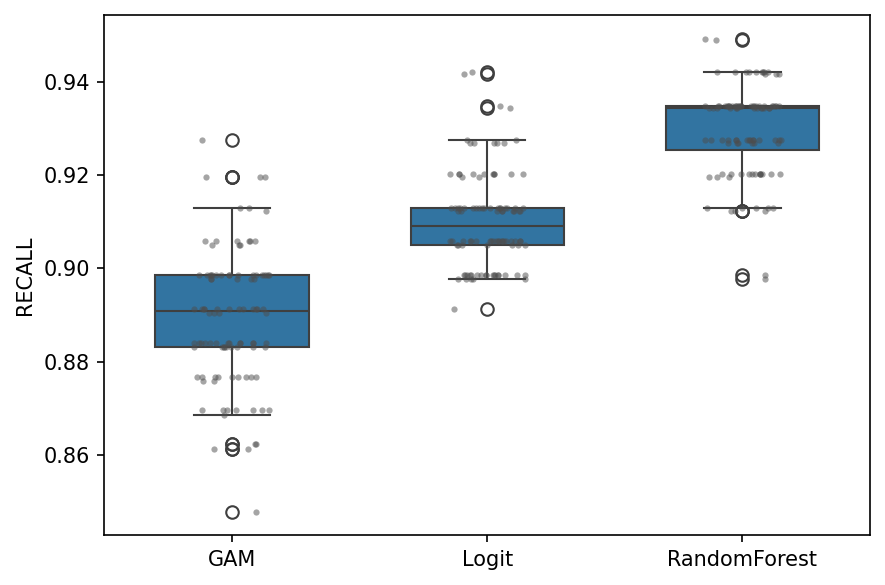

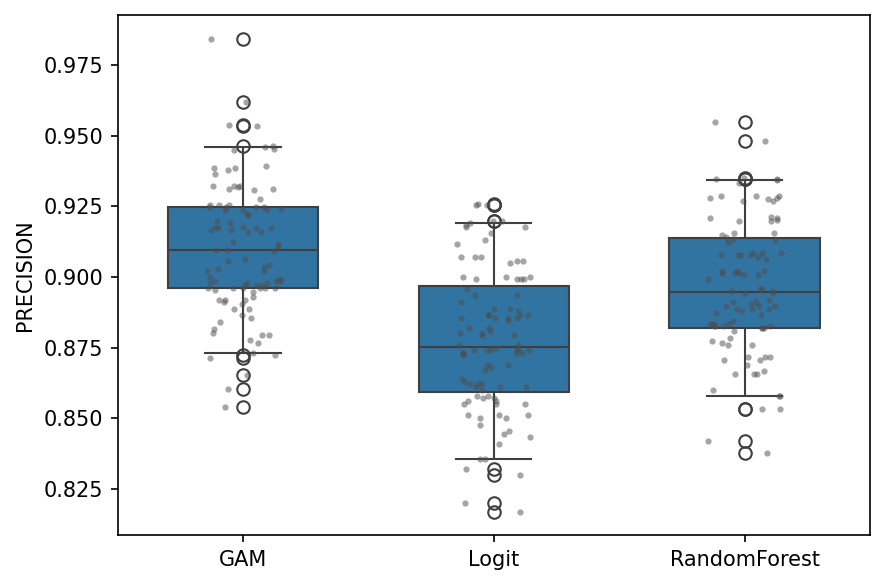

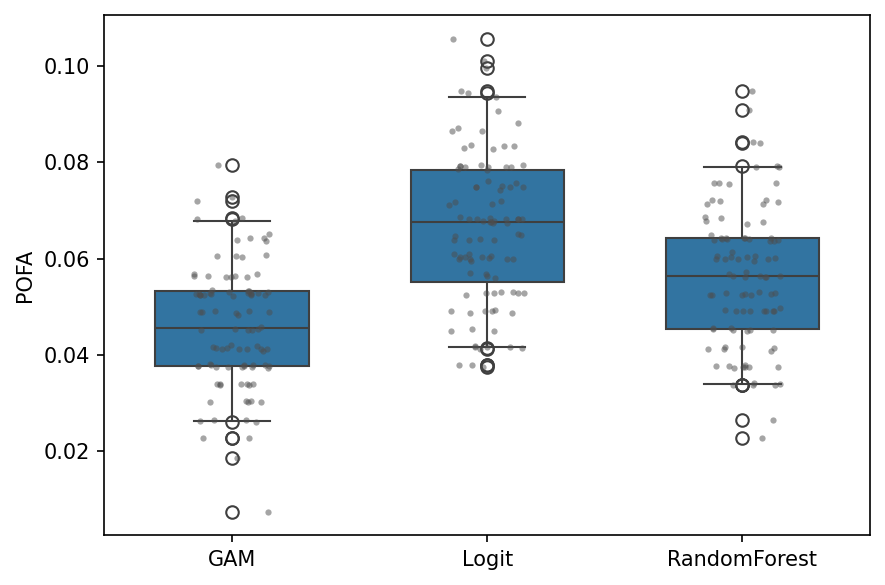

In [11]:
# =========================
# 2) BOXPLOTS por métrica (modelo en x)
# =========================
# out_fig_dir = "/home/oisanchezp/Thesis/figuras"
# os.makedirs(out_fig_dir, exist_ok=True)

for m in metrics:
    plt.figure(figsize=(6, 4), dpi=150)

    sns.boxplot(
        data=df,
        x="modelo",
        y=m,
        whis=(5, 95),
        width=0.6
    )

    sns.stripplot(
        data=df,
        x="modelo",
        y=m,
        color="0.3",
        alpha=0.5,
        jitter=0.15,
        size=3
    )

    plt.ylabel(m.upper())
    plt.xlabel("")
    plt.tight_layout()

    #out_png = os.path.join(out_fig_dir, f"{m}_boxplot_modelos.png")
    #plt.savefig(out_png, dpi=300)
    plt.show()

    #print(f"Figura guardada: {out_png}")



=== Métrica: AUC ===


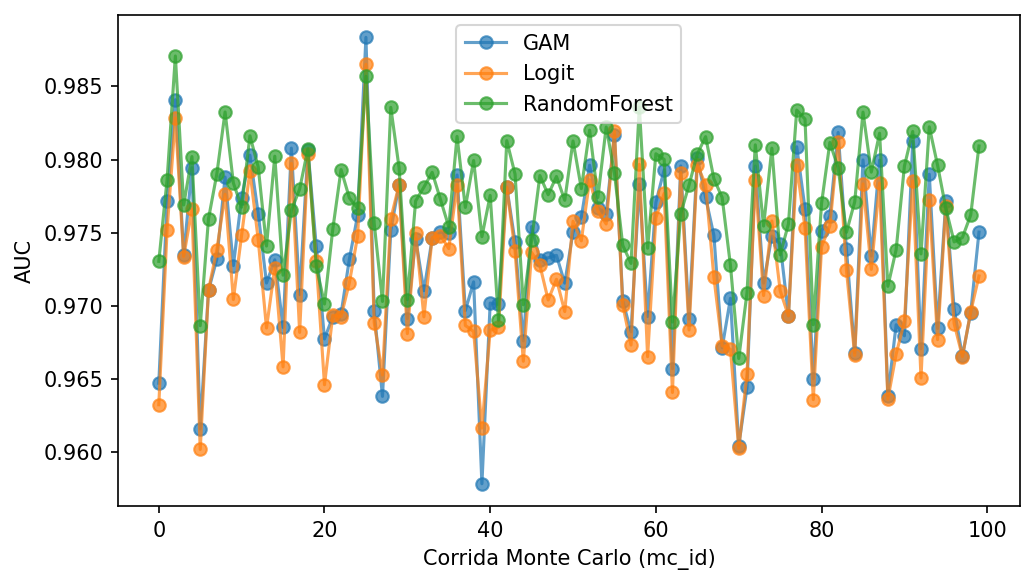


=== Métrica: F1 ===


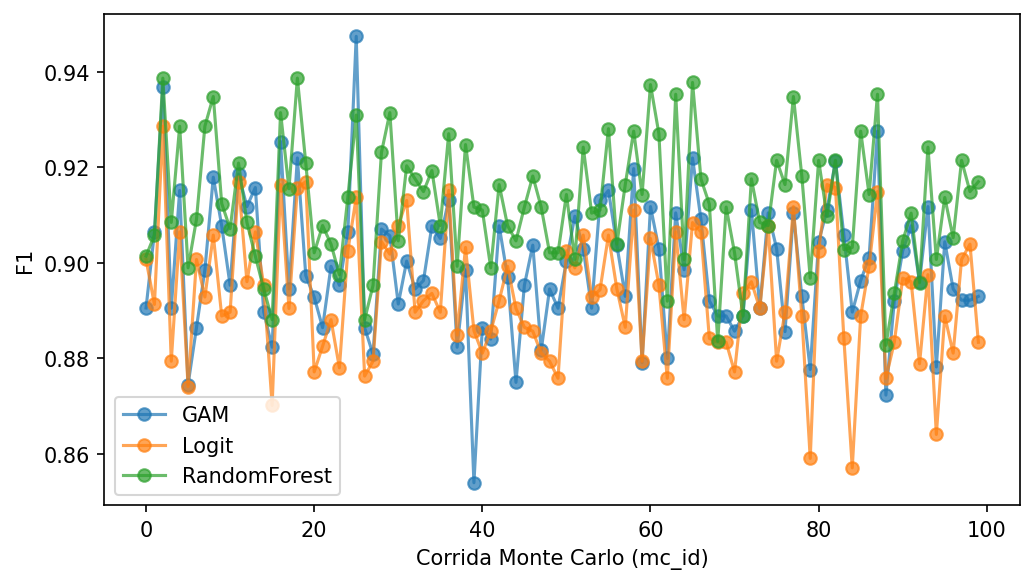


=== Métrica: RECALL ===


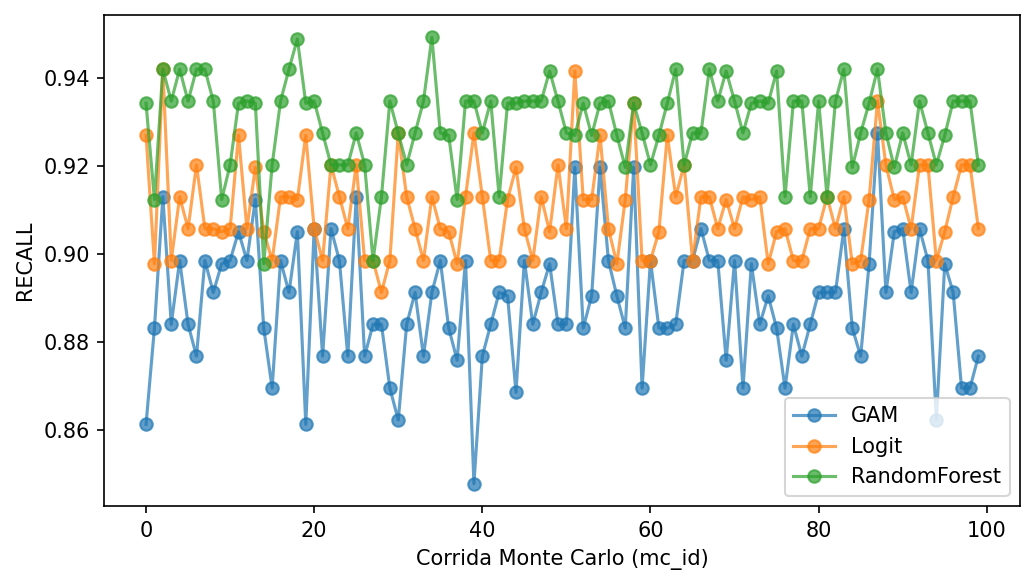


=== Métrica: PRECISION ===


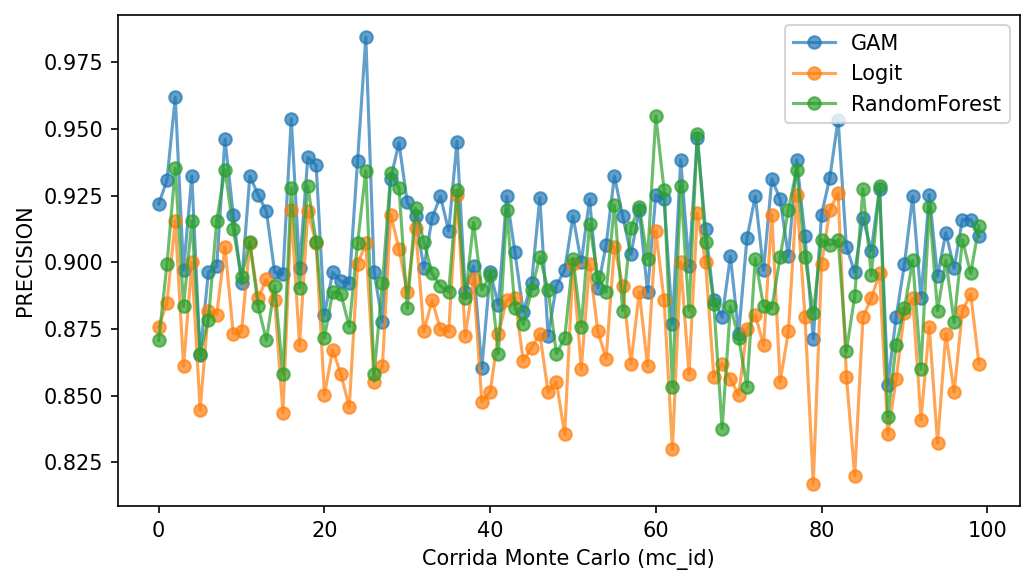


=== Métrica: POFA ===


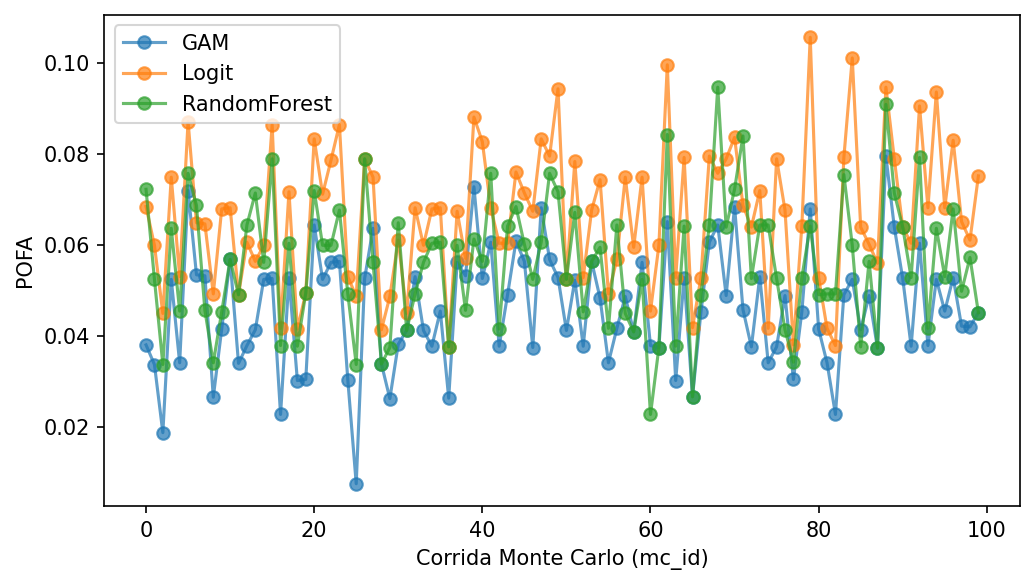

In [12]:
# =========================
# 3) LÍNEAS por métrica (x=mc_id, y=m, color=modelo)
# =========================
for m in metrics:
    pivot = df.pivot(index="mc_id", columns="modelo", values=m).sort_index()

    plt.figure(figsize=(7, 4), dpi=150)

    for modelo in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[modelo],
            marker="o",
            linestyle="-",
            alpha=0.7,
            label=modelo
        )

    plt.xlabel("Corrida Monte Carlo (mc_id)")
    plt.ylabel(m.upper())
    plt.legend()
    plt.tight_layout()

    #out_png = os.path.join(out_fig_dir, f"{m}_lineas_por_mc.png")
    #plt.savefig(out_png, dpi=300)
    print(f"\n=== Métrica: {m.upper()} ===")
    plt.show()

In [13]:
winners = pivot.idxmax(axis=1).value_counts().reset_index()
winners.columns = ["modelo_ganador", "n_corridas"]
winners["proporcion"] = winners["n_corridas"] / pivot.shape[0]

print(winners)


  modelo_ganador  n_corridas  proporcion
0          Logit          87        0.87
1   RandomForest          13        0.13



=== Conteo: TP ===


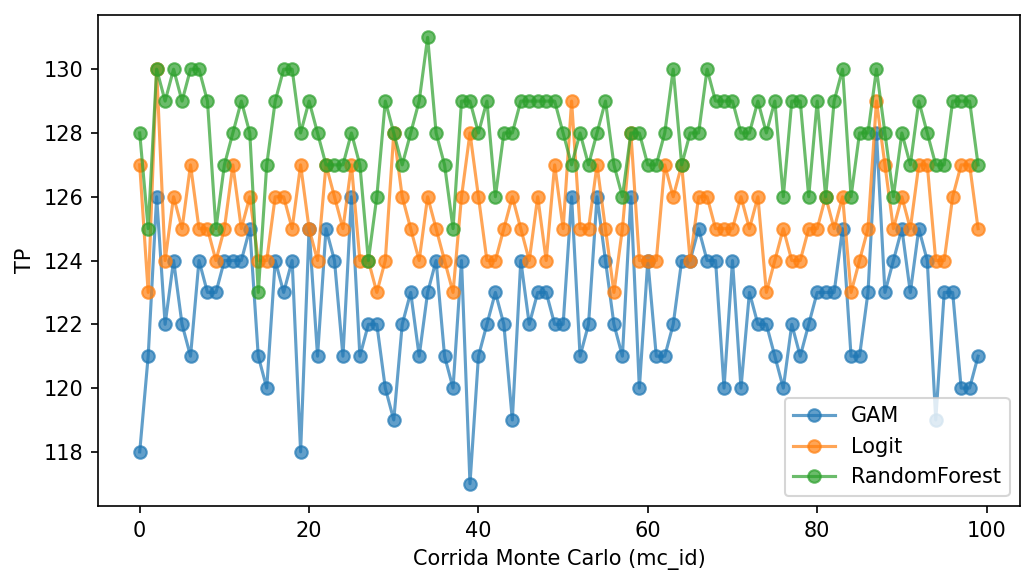


=== Conteo: TN ===


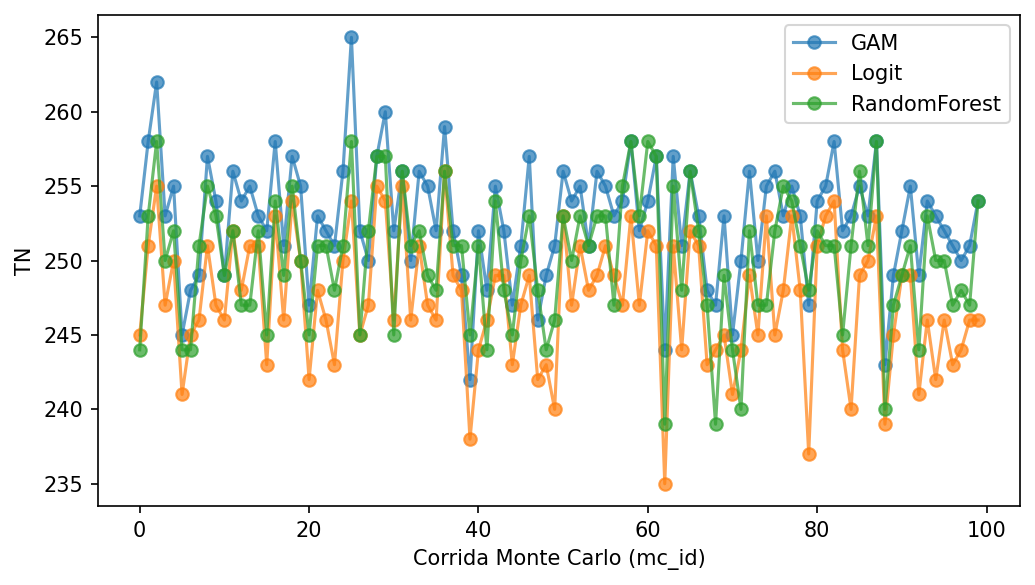


=== Conteo: FP ===


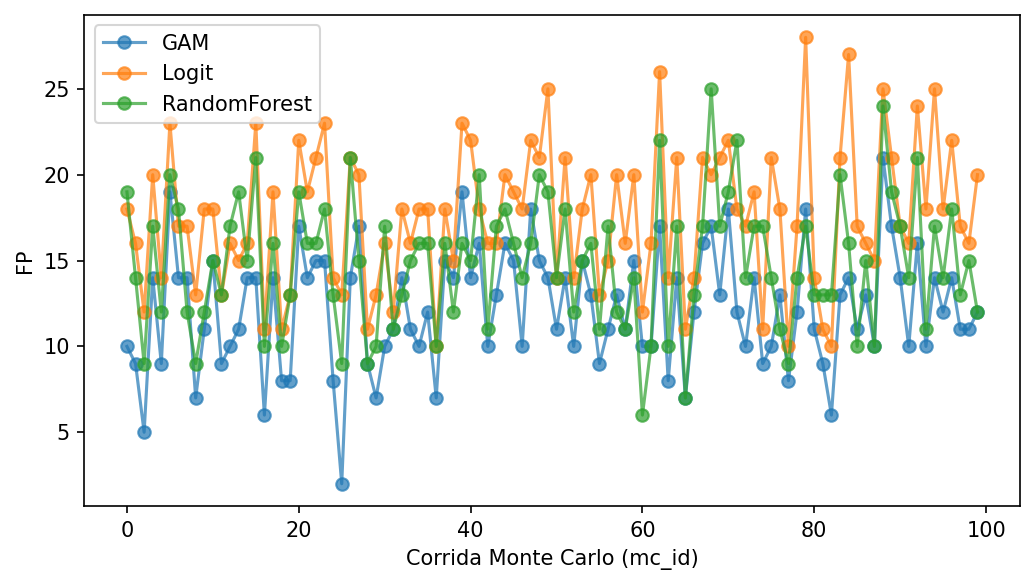


=== Conteo: FN ===


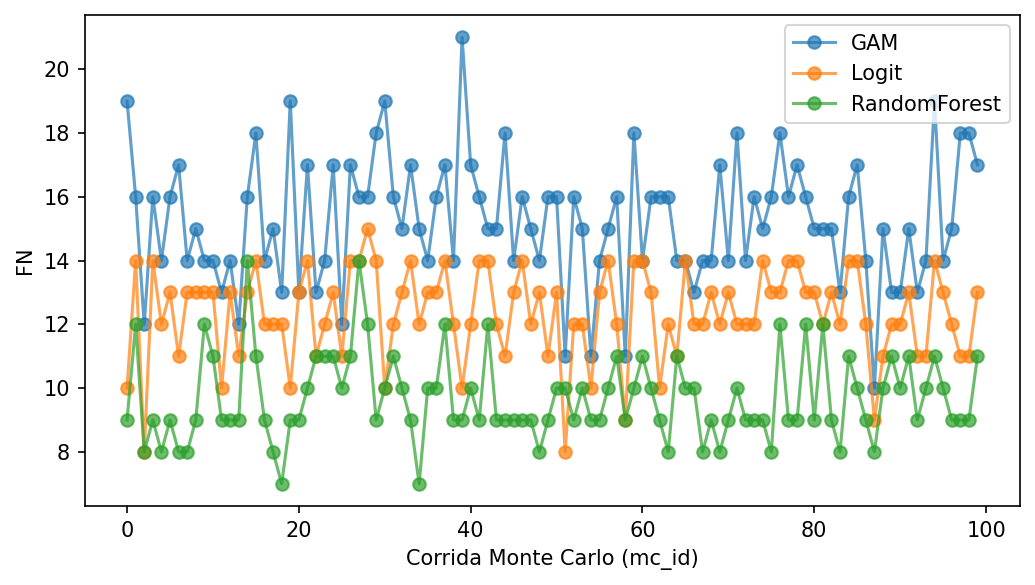

In [14]:
# =========================
# 4) TP/TN/FP/FN: líneas por corrida, 1 figura por variable
#    (x=mc_id, y=conteo, color=modelo)
# =========================
for c in count_cols:
    pivot_c = df.pivot(index="mc_id", columns="modelo", values=c).sort_index()

    plt.figure(figsize=(7, 4), dpi=150)

    for modelo in pivot_c.columns:
        plt.plot(
            pivot_c.index,
            pivot_c[modelo],
            marker="o",
            linestyle="-",
            alpha=0.7,
            label=modelo
        )

    plt.xlabel("Corrida Monte Carlo (mc_id)")
    plt.ylabel(c.upper())
    plt.legend()
    plt.tight_layout()

    #out_png = os.path.join(out_fig_dir, f"{c}_lineas_por_mc.png")
    #plt.savefig(out_png, dpi=300)
    print(f"\n=== Conteo: {c.upper()} ===")
    plt.show()

    #print(f"Figura guardada: {out_png}")

### **FIJAR UNA VARIABLES PARA MIRAR COMO SE COMPORTA LA OTRA VARIABLE**



In [8]:
import numpy as np
import pandas as pd
from pygam import LogisticGAM, s
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# df_final: DataFrame con columnas:
# '1d', '34d' (1 + 33), 'Mes', 'ONI', 'si_no'
df_final = pd.read_csv("/home/oisanchezp/Thesis/data/processed/slope_units_si_no_20251115.csv")
df = df_final.copy()
df = df[df["si_no"].isin([0, 1])]
df = df.dropna(subset=["1d", "34d", "Mes", "ONI", "si_no"])

df["Mes"] = df["Mes"].astype(float)
df["si_no"] = df["si_no"].astype(int)

# Construir T y P
T = df["1d"].values
P = (df["34d"] - df["1d"]).values   # tus 33 días preparatorios

X = np.column_stack([
    T,
    P,
    df["Mes"].values.astype(float),
    df["ONI"].values.astype(float)
])
y = df["si_no"].values

terms = s(0, n_splines=5) + s(1, n_splines=5) + s(2, n_splines=5) + s(3, n_splines=5)

# Seleccionar lambda óptimo como antes
lam_grid = np.logspace(0, 3, 5)

def get_best_lambda(X, y):
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    best_lam, best_auc = None, -np.inf
    for lam in lam_grid:
        gam = LogisticGAM(terms, lam=lam).fit(X_tr, y_tr)
        auc = roc_auc_score(y_va, gam.predict_proba(X_va))
        if auc > best_auc:
            best_auc, best_lam = auc, lam
    return best_lam

best_lam = get_best_lambda(X, y)
gam = LogisticGAM(terms, lam=best_lam).fit(X, y)


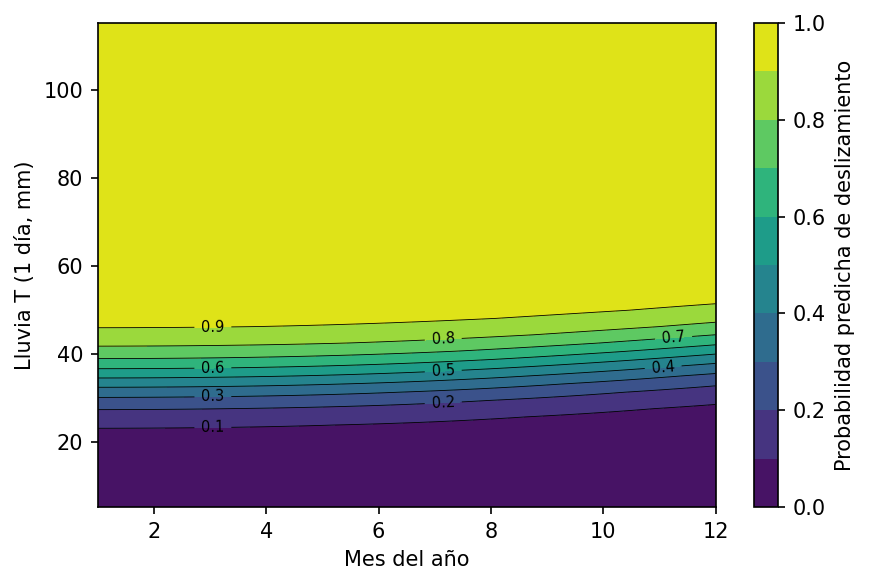

In [10]:
import matplotlib.pyplot as plt

# Rango de T y Mes para la malla
T_min, T_max = np.percentile(T, [1, 99])
P_min, P_max = np.percentile(P, [1, 99])

t_vals = np.linspace(T_min, T_max, 60)      # eje vertical
mes_vals = np.linspace(1, 12, 60)          # eje horizontal

MES, TGRID = np.meshgrid(mes_vals, t_vals)

# Fijamos P y ONI:
P_fix = np.percentile(P, 50)   # suelo "seco"
ONI_fix = 0.0                 # ENSO neutro (ajusta si quieres Niña/El Niño)

X_grid = np.column_stack([
    TGRID.ravel(),
    np.full(TGRID.size, P_fix),
    MES.ravel(),
    np.full(TGRID.size, ONI_fix)
])

prob_grid = gam.predict_proba(X_grid).reshape(TGRID.shape)

plt.figure(figsize=(6, 4), dpi=150)
cs = plt.contourf(
    MES,           # x = Mes
    TGRID,         # y = T
    prob_grid,     # probabilidad
    levels=np.linspace(0, 1, 11)
)
cbar = plt.colorbar(cs)
cbar.set_label("Probabilidad predicha de deslizamiento")

# Contornos etiquetados (como en el paper)
contours = plt.contour(MES, TGRID, prob_grid,
                       levels=np.arange(0.1, 1.0, 0.1),
                       colors="k", linewidths=0.4)
plt.clabel(contours, inline=True, fontsize=7, fmt="%.1f")

plt.xlabel("Mes del año")
plt.ylabel("Lluvia T (1 día, mm)")
plt.tight_layout()
#plt.savefig("/home/oisanchezp/Thesis/figuras/GAM_T_vs_Mes.png", dpi=300)
plt.show()


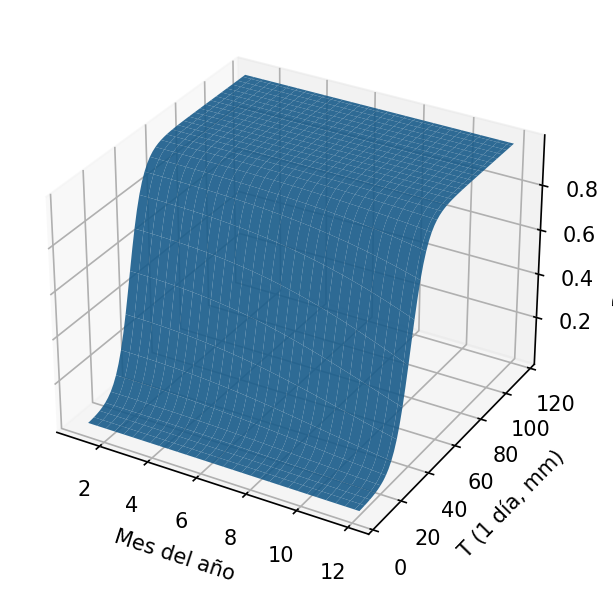

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # solo para activar proyección 3d

fig = plt.figure(figsize=(6, 4), dpi=150)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(
    MES, TGRID, prob_grid,
    linewidth=0, antialiased=True, alpha=0.9
)
ax.set_xlabel("Mes del año")
ax.set_ylabel("T (1 día, mm)")
ax.set_zlabel("Probabilidad")
plt.tight_layout()
#plt.savefig("/home/oisanchezp/Thesis/figuras/GAM_T_vs_Mes_3D.png", dpi=300)
plt.show()


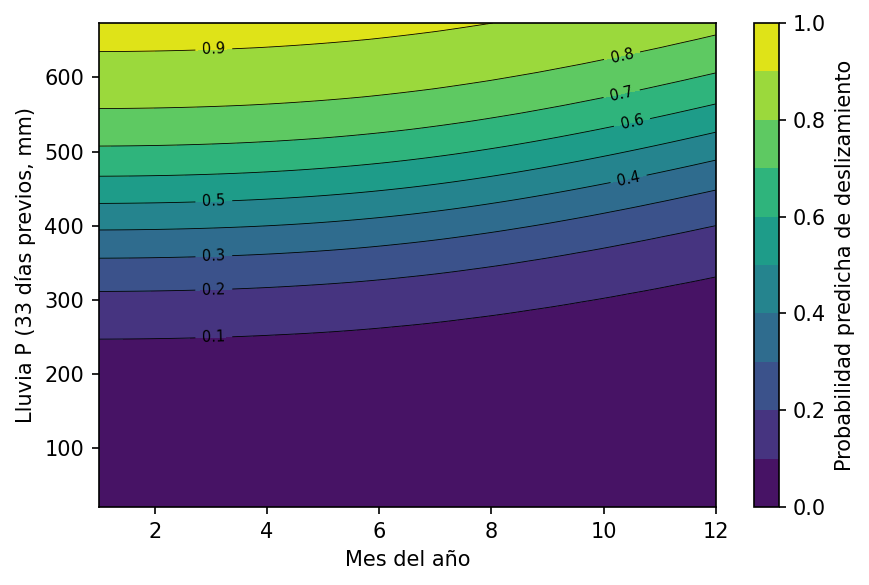

In [16]:
p_vals = np.linspace(P_min, P_max+200, 60)
mes_vals = np.linspace(1, 12, 60)

MES2, PGRID = np.meshgrid(mes_vals, p_vals)

T_fix = np.percentile(T, 50)   # lluvia disparadora baja
ONI_fix = 0.0                 # ENSO neutro

X_grid2 = np.column_stack([
    np.full(PGRID.size, T_fix),
    PGRID.ravel(),
    MES2.ravel(),
    np.full(PGRID.size, ONI_fix)
])

prob_grid2 = gam.predict_proba(X_grid2).reshape(PGRID.shape)

plt.figure(figsize=(6, 4), dpi=150)
cs2 = plt.contourf(
    MES2, PGRID, prob_grid2,
    levels=np.linspace(0, 1, 11)
)
cbar2 = plt.colorbar(cs2)
cbar2.set_label("Probabilidad predicha de deslizamiento")

contours2 = plt.contour(MES2, PGRID, prob_grid2,
                        levels=np.arange(0.1, 1.0, 0.1),
                        colors="k", linewidths=0.4)
plt.clabel(contours2, inline=True, fontsize=7, fmt="%.1f")

plt.xlabel("Mes del año")
plt.ylabel("Lluvia P (33 días previos, mm)")
plt.tight_layout()
#plt.savefig("/home/oisanchezp/Thesis/figuras/GAM_P_vs_Mes.png", dpi=300)
plt.show()


In [ ]:
oni_vals = np.linspace(df["ONI"].min(), df["ONI"].max(), 60)
p_vals = np.linspace(P_min, P_max, 60)

ONI_GRID, PGRID3 = np.meshgrid(oni_vals, p_vals)

Mes_fix = 5.0   # mayo, ajusta según te interese
T_fix  = np.percentile(T, 5)

X_grid3 = np.column_stack([
    np.full(PGRID3.size, T_fix),
    PGRID3.ravel(),
    np.full(PGRID3.size, Mes_fix),
    ONI_GRID.ravel()
])

prob_grid3 = gam.predict_proba(X_grid3).reshape(PGRID3.shape)
# y luego haces el contourf como antes


### **UMBRALES**



In [94]:
import numpy as np
import pandas as pd
from pygam import LogisticGAM, s
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

# df: dataset final que quieras usar para definir umbrales
df_final = pd.read_csv("/home/oisanchezp/Thesis/data/processed/slope_units_si_no_20251115.csv")
df = df_final.copy()
df = df[df["si_no"].isin([0,1])]
df = df.dropna(subset=["1d", "34d", "Mes", "ONI", "si_no"])

df["Mes"] = df["Mes"].astype(float)
df["si_no"] = df["si_no"].astype(int)

T = df["1d"].values
P = (df["34d"] - df["1d"]).values
Mes = df["Mes"].values.astype(float)
ONI = df["ONI"].values.astype(float)
y = df["si_no"].values

# matriz de predictores y respuesta
X = T + P + Mes + ONI
X = np.column_stack([T, P, Mes, ONI])
y = df["si_no"].values

# split 70/30 estratificado
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

terms = s(0, n_splines=5) + s(1, n_splines=5) + s(2, n_splines=5) + s(3, n_splines=5)

lam_grid = np.logspace(0, 3, 5)

def get_best_lambda(X_tr, y_tr):
    # si quieres, haz un split interno aquí, o usa CV;
    # para simplificar, uso todo el train
    from sklearn.metrics import roc_auc_score
    best_lam, best_auc = None, -np.inf
    for lam in lam_grid:
        gam_tmp = LogisticGAM(terms, lam=lam).fit(X_tr, y_tr)
        auc = roc_auc_score(y_tr, gam_tmp.predict_proba(X_tr))
        if auc > best_auc:
            best_auc, best_lam = auc, lam
    return best_lam

best_lam = get_best_lambda(X_train, y_train)

gam = LogisticGAM(terms, lam=best_lam).fit(X_train, y_train)

print("AUROC final:", roc_auc_score(y_val, gam.predict_proba(X_val)))

AUROC final: 0.9861442904921165


In [95]:
# Probabilidades para todas las observaciones reales
y_prob = gam.predict_proba(X)

fpr, tpr, thresholds = roc_curve(y, y_prob)
tnr = 1 - fpr

# --- TPR 95 % ---
target_tpr = 0.95
idx_tpr95 = np.argmin(np.abs(tpr - target_tpr))
thr_tpr95 = thresholds[idx_tpr95]

# --- TNR 95 % ---
target_tnr = 0.95
idx_tnr95 = np.argmin(np.abs(tnr - target_tnr))
thr_tnr95 = thresholds[idx_tnr95]

# --- Cutpoint óptimo (mínima distancia a (0,1)) ---
dist = np.sqrt((fpr - 0)**2 + (1 - tpr)**2)
idx_opt  = np.argmin(dist)
thr_opt  = thresholds[idx_opt]

print("TPR95:", tpr[idx_tpr95], "TNR:", tnr[idx_tpr95], "thr:", thr_tpr95)
print("TNR95:", tnr[idx_tnr95], "TPR:", tpr[idx_tnr95], "thr:", thr_tnr95)
print("OPT:  ", tpr[idx_opt],   "TNR:", tnr[idx_opt],   "thr:", thr_opt)


TPR95: 0.9497816593886463 TNR: 0.9462129527991219 thr: 0.36014206136011684
TNR95: 0.9484083424807903 TPR: 0.9344978165938864 thr: 0.3910780849956545
OPT:   0.9541484716157205 TNR: 0.9451152579582875 thr: 0.3359269657384649


In [116]:
import matplotlib.pyplot as plt

# Rangos de T y P
T_min, T_max = 0, 200
P_min, P_max = 0, 600

t_vals = np.linspace(T_min, T_max, 120)
p_vals = np.linspace(P_min, P_max, 120)
PP, TT = np.meshgrid(p_vals, t_vals)

# fijar Mes y ONI
mes_fix = 1   # enero
oni_fix = 2.0

X_grid = np.column_stack([
    TT.ravel(),
    PP.ravel(),
    np.full(TT.size, mes_fix),
    np.full(TT.size, oni_fix)
])
prob_grid = gam.predict_proba(X_grid).reshape(TT.shape)


In [117]:
from sklearn.metrics import roc_auc_score

y_prob_all = gam.predict_proba(X)
fpr, tpr, thresholds = roc_curve(y, y_prob_all)
tnr = 1 - fpr

# TPR 95 %
target_tpr = 0.95
idx_tpr95 = np.argmin(np.abs(tpr - target_tpr))
thr_tpr95 = thresholds[idx_tpr95]

# TNR 95 %
target_tnr = 0.95
idx_tnr95 = np.argmin(np.abs(tnr - target_tnr))
thr_tnr95 = thresholds[idx_tnr95]

# Óptimo
dist = np.sqrt((fpr - 0)**2 + (1 - tpr)**2)
idx_opt = np.argmin(dist)
thr_opt = thresholds[idx_opt]

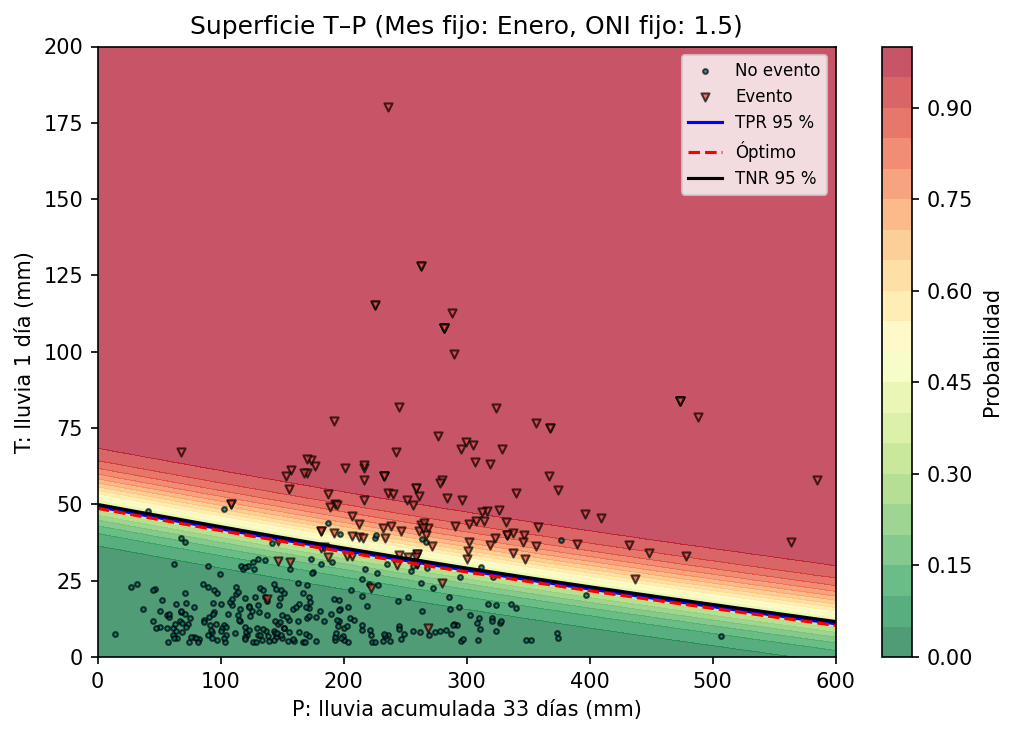

In [118]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# Fondo de probabilidad
cs = ax.contourf(
    PP, TT, prob_grid,
    levels=np.linspace(0, 1, 21), cmap="RdYlGn_r", alpha=0.7
)
cbar = fig.colorbar(cs, ax=ax)
cbar.set_label("Probabilidad")

P_val = X_val[:,1]
T_val = X_val[:,0]
# Poner datos reales encima
ax.scatter(P_val[y_val==0], T_val[y_val==0], s=5, c="darkcyan", marker = "o", edgecolors='k', alpha=0.7, label="No evento")
ax.scatter(P_val[y_val==1], T_val[y_val==1], s=15, c="#E74C3C", marker="v", edgecolors='k', alpha=0.7, label="Evento")

# Curvas de nivel para los tres umbrales
ax.contour(PP, TT, prob_grid, levels=[thr_tpr95], colors="blue",  linestyles="solid")
ax.contour(PP, TT, prob_grid, levels=[thr_opt],   colors="red",   linestyles="dashed")
ax.contour(PP, TT, prob_grid, levels=[thr_tnr95], colors="black", linestyles="solid")

# Truco para leyenda de las líneas
from matplotlib.lines import Line2D
line_tpr = Line2D([], [], color="blue",  linestyle="solid",  label="TPR 95 %")
line_opt = Line2D([], [], color="red",   linestyle="dashed", label="Óptimo")
line_tnr = Line2D([], [], color="black", linestyle="solid",  label="TNR 95 %")

handles, labels = ax.get_legend_handles_labels()
handles.extend([line_tpr, line_opt, line_tnr])
ax.legend(handles=handles, fontsize=8, loc="upper right")

ax.set_xlabel("P: lluvia acumulada 33 días (mm)")
ax.set_ylabel("T: lluvia 1 día (mm)")
ax.set_title("Superficie T–P (Mes fijo: Enero, ONI fijo: 1.5)")
plt.tight_layout()
#plt.savefig("/home/oisanchezp/Thesis/figuras/TP_global_umbral.png", dpi=300)
plt.show()


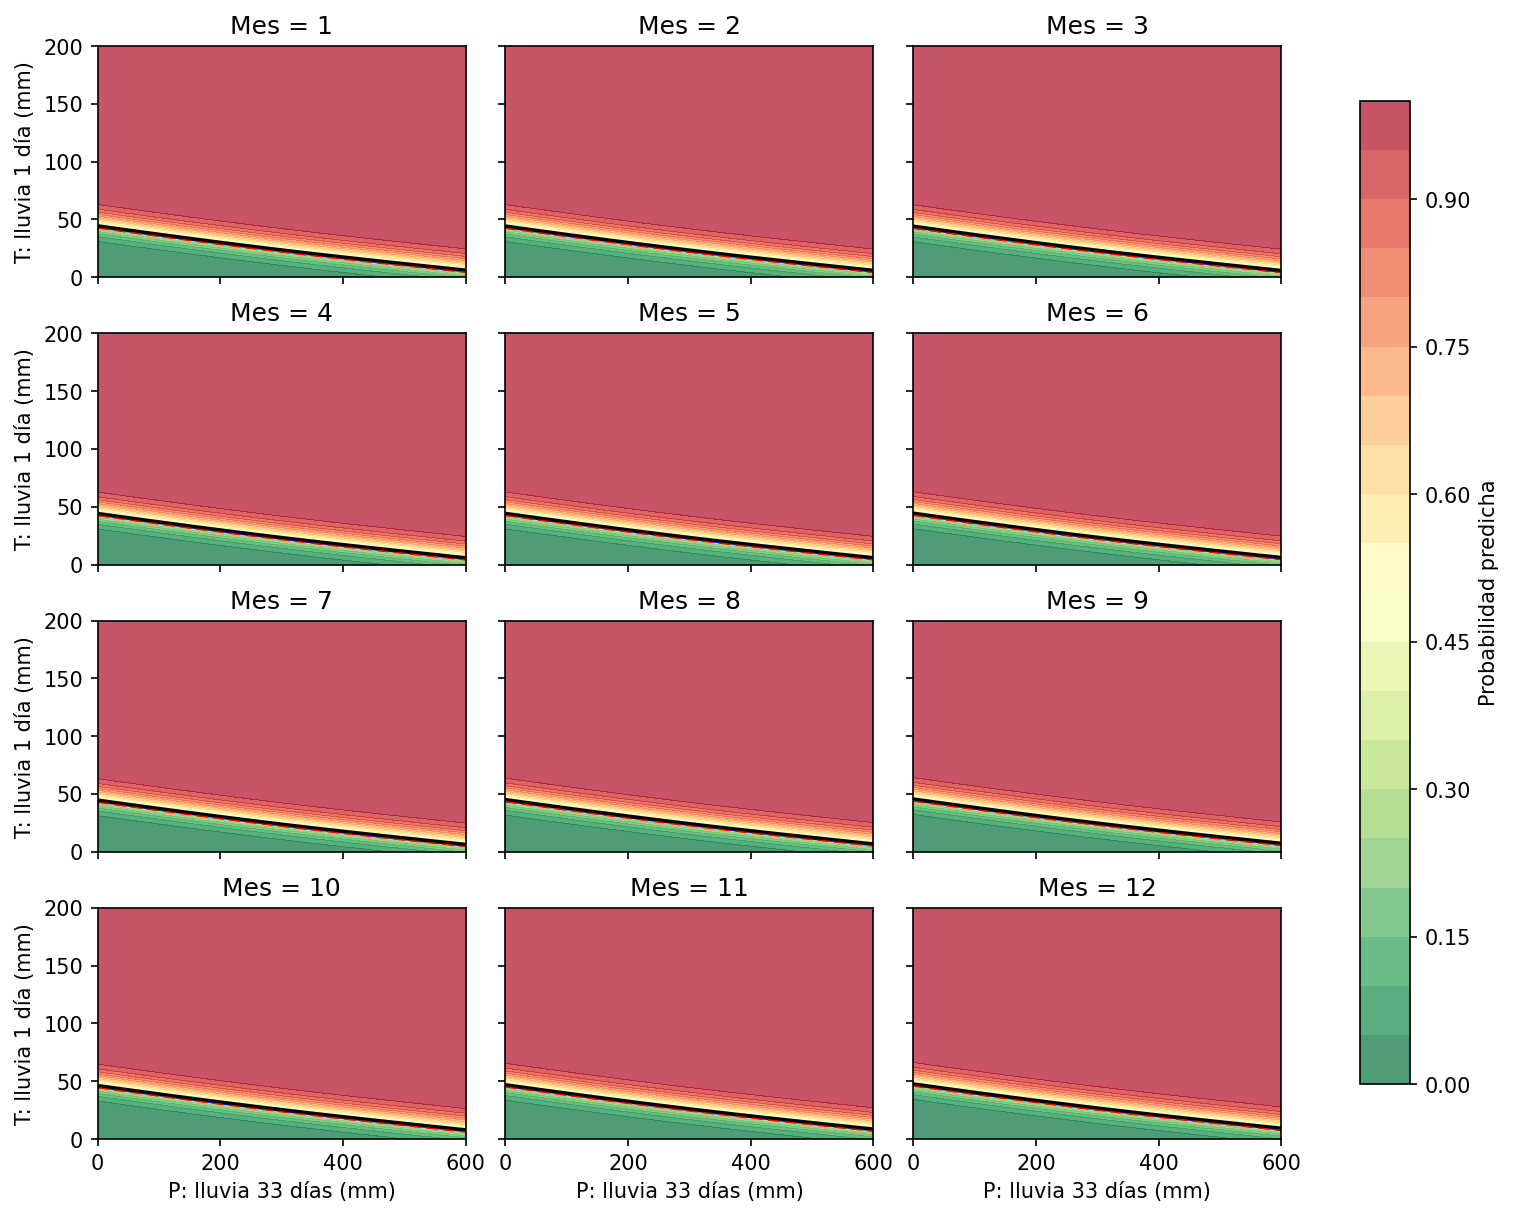

In [92]:
mes_list = [1, 2, 3, 4, 5, 6, 7, 8, 9,10, 11, 12]   # ajusta según tus estaciones
oni_fix = -1.0

fig, axes = plt.subplots(4, 3, figsize=(10, 8), dpi=150, sharex=True, sharey=True,
                         constrained_layout=True)

for ax, m in zip(axes.ravel(), mes_list):
    X_grid_m = np.column_stack([
        TT.ravel(),                # T
        PP.ravel(),                # P
        np.full(TT.size, m),       # Mes fijo
        np.full(TT.size, oni_fix)  # ONI fijo
    ])
    prob_m = gam.predict_proba(X_grid_m).reshape(TT.shape)

    cs = ax.contourf(
        PP, TT, prob_m,
        levels=np.linspace(0, 1, 21), cmap="RdYlGn_r", alpha=0.7
    )

    # Curvas de nivel para los tres cutpoints
    ax.contour(PP, TT, prob_m, levels=[thr_tpr95], colors="blue",  linestyles="solid")
    ax.contour(PP, TT, prob_m, levels=[thr_opt],   colors="red",   linestyles="dashed")
    ax.contour(PP, TT, prob_m, levels=[thr_tnr95], colors="black", linestyles="solid")

    ax.set_title(f"Mes = {int(m)}")
#mover colorbar fuera de los graficos queda a la derecha
# 👇 colorbar a la derecha de todos los subplots
cbar = fig.colorbar(
    cs, ax=axes, location="right",
    label="Probabilidad predicha", shrink=0.9
)
for ax in axes[3]:
    ax.set_xlabel("P: lluvia 33 días (mm)")
for ax in axes[:,0]:
    ax.set_ylabel("T: lluvia 1 día (mm)")

#plt.savefig("/home/oisanchezp/Thesis/figuras/TP_por_mes_umbral.png", dpi=300)
plt.show()
